# Sensor-Based Air Pollutant Concentration Regression
**Machine Learning · Assignment #1 · Air Quality Monitoring (UCI Air Quality dataset)**

Predict a ground-truth pollutant concentration from low-cost metal-oxide sensor signals and weather variables, using Linear / Polynomial regression (from scratch + scikit-learn) and Decision Tree regressors.

| Stage | Contents | Status |
|---|---|---|
| **1. Data Preparation** | Load, EDA, missing values, target & feature selection, scaling, 80/20 split | ✅ this section |
| **2. Model Training** | Linear & polynomial regression from scratch, sklearn cross-check, Decision Trees (`max_depth` sweep), CV tuning, ablations | ✅ this section |
| 3. Model Evaluation | MSE, RMSE, R²; metric vs. epoch and vs. tree depth | ⏳ |
| 4. Model Visualization | Tree plot (`max_depth=3`), feature importances | ⏳ |
| 5. Baseline Comparison | Linear vs. Decision Tree | ⏳ |
| 6. Discussion | Short written answers | ⏳ |

## Stage 1 — Data Preparation
### 1.0 Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42                       # single seed -> reproducible split
DATA_PATH = "../../data/air+quality/AirQualityUCI.csv"   # relative to src/notebooks/

# Plot style: clean, recessive grid, colour-blind-safe (Okabe-Ito) palette
BLUE, ORANGE, GREEN, RED, GREY = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#7F7F7F"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "grid.alpha": 0.35, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.max_columns", 30, "display.width", 140, "display.float_format", "{:,.3f}".format)

### 1.1 Load the data
The UCI CSV is **semicolon-separated with decimal commas**, and has two trailing empty columns and trailing blank rows (an Excel export artefact). We parse it accordingly.

In [2]:
raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
print(f"Raw file shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head())
display(raw.tail(3))

Raw file shape: 9,471 rows x 17 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.600,"1,360.000",150.000,11.900,"1,046.000",166.000,"1,056.000",113.000,"1,692.000","1,268.000",13.600,48.900,0.758,NaN,NaN
1,10/03/2004,19.00.00,2.000,"1,292.000",112.000,9.400,955.000,103.000,"1,174.000",92.000,"1,559.000",972.000,13.300,47.700,0.726,NaN,NaN
2,10/03/2004,20.00.00,2.200,"1,402.000",88.000,9.000,939.000,131.000,"1,140.000",114.000,"1,555.000","1,074.000",11.900,54.000,0.750,NaN,NaN
3,10/03/2004,21.00.00,2.200,"1,376.000",80.000,9.200,948.000,172.000,"1,092.000",122.000,"1,584.000","1,203.000",11.000,60.000,0.787,NaN,NaN
4,10/03/2004,22.00.00,1.600,"1,272.000",51.000,6.500,836.000,131.000,"1,205.000",116.000,"1,490.000","1,110.000",11.200,59.600,0.789,NaN,NaN


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Structural cleaning (artefacts of the file format)

In [3]:
df = raw.dropna(how="all").dropna(axis=1, how="all").copy()   # drop blank rows / the 2 empty 'Unnamed' columns
print(f"After removing blank rows/columns: {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"(removed {raw.shape[0]-df.shape[0]} blank rows, {raw.shape[1]-df.shape[1]} empty columns)")

# Build a proper timestamp and index the data by it (dates are dd/mm/yyyy, times use '.' separators)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H.%M.%S")
df = df.drop(columns=["Date", "Time"]).set_index("Datetime").sort_index()

GT_COLS     = ["CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]       # candidate targets
SENSOR_COLS = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
WEATHER_COLS = ["T", "RH", "AH"]
FEATURE_CANDIDATES = SENSOR_COLS + WEATHER_COLS

print("\nTime coverage :", df.index.min(), "->", df.index.max())
print("Duplicate rows:", df.duplicated().sum(), "| duplicate timestamps:", df.index.duplicated().sum())
gaps = df.index.to_series().diff().value_counts()
print("Gaps between consecutive timestamps:\n", gaps.to_string())

After removing blank rows/columns: 9,357 rows x 15 columns (removed 114 blank rows, 2 empty columns)

Time coverage : 2004-03-10 18:00:00 -> 2005-04-04 14:00:00
Duplicate rows: 31 | duplicate timestamps: 0
Gaps between consecutive timestamps:
 Datetime
0 days 01:00:00    9356


**Observations.** The series is a clean, gap-free hourly grid (every step is exactly 1 h) with no duplicates. Note the data really ends in **April 2005**, slightly beyond the "March 2004 – February 2005" in the brief — it is just over one year, so every season (and weather regime) appears at least once.

### 1.3 Schema, dtypes and raw summary statistics

In [4]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "role": ["target candidate" if c in GT_COLS else "sensor feature" if c in SENSOR_COLS else "weather feature" for c in df.columns],
    "n_unique": df.nunique(),
})
display(schema)
print("RAW describe() (before treating -200 as missing):")
display(df.describe().T)

,dtype,role,n_unique
CO(GT),float64,target candidate,97
PT08.S1(CO),float64,sensor feature,1042
NMHC(GT),float64,target candidate,430
C6H6(GT),float64,target candidate,408
PT08.S2(NMHC),float64,sensor feature,1246
NOx(GT),float64,target candidate,926
PT08.S3(NOx),float64,sensor feature,1222
NO2(GT),float64,target candidate,284
PT08.S4(NO2),float64,sensor feature,1604
PT08.S5(O3),float64,sensor feature,1744


RAW describe() (before treating -200 as missing):


,count,mean,std,min,25%,50%,75%,max
CO(GT),"9,357.000",-34.208,77.657,-200.000,0.600,1.500,2.600,11.900
PT08.S1(CO),"9,357.000","1,048.990",329.833,-200.000,921.000,"1,053.000","1,221.000","2,040.000"
NMHC(GT),"9,357.000",-159.090,139.789,-200.000,-200.000,-200.000,-200.000,"1,189.000"
C6H6(GT),"9,357.000",1.866,41.380,-200.000,4.000,7.900,13.600,63.700
PT08.S2(NMHC),"9,357.000",894.595,342.333,-200.000,711.000,895.000,"1,105.000","2,214.000"
NOx(GT),"9,357.000",168.617,257.434,-200.000,50.000,141.000,284.000,"1,479.000"
PT08.S3(NOx),"9,357.000",794.990,321.994,-200.000,637.000,794.000,960.000,"2,683.000"
NO2(GT),"9,357.000",58.149,126.940,-200.000,53.000,96.000,133.000,340.000
PT08.S4(NO2),"9,357.000","1,391.480",467.210,-200.000,"1,185.000","1,446.000","1,662.000","2,775.000"
PT08.S5(O3),"9,357.000",975.072,456.938,-200.000,700.000,942.000,"1,255.000","2,523.000"


**Observation — hidden missing values.** `min` is **-200** in every column. Concentrations, humidity and sensor voltages cannot be negative, and `T = -200 °C` is physically impossible. The UCI documentation states that **-200 is the missing-value sentinel**. Left untreated it would badly distort every statistic, scaler and regression fit, so we convert it to `NaN` first.

### 1.4 Missing-value diagnosis

,missing,missing_%,valid
NMHC(GT),8443,90.2%,914
CO(GT),1683,18.0%,7674
NO2(GT),1642,17.5%,7715
NOx(GT),1639,17.5%,7718
PT08.S1(CO),366,3.9%,8991
C6H6(GT),366,3.9%,8991
PT08.S2(NMHC),366,3.9%,8991
PT08.S3(NOx),366,3.9%,8991
PT08.S4(NO2),366,3.9%,8991
PT08.S5(O3),366,3.9%,8991


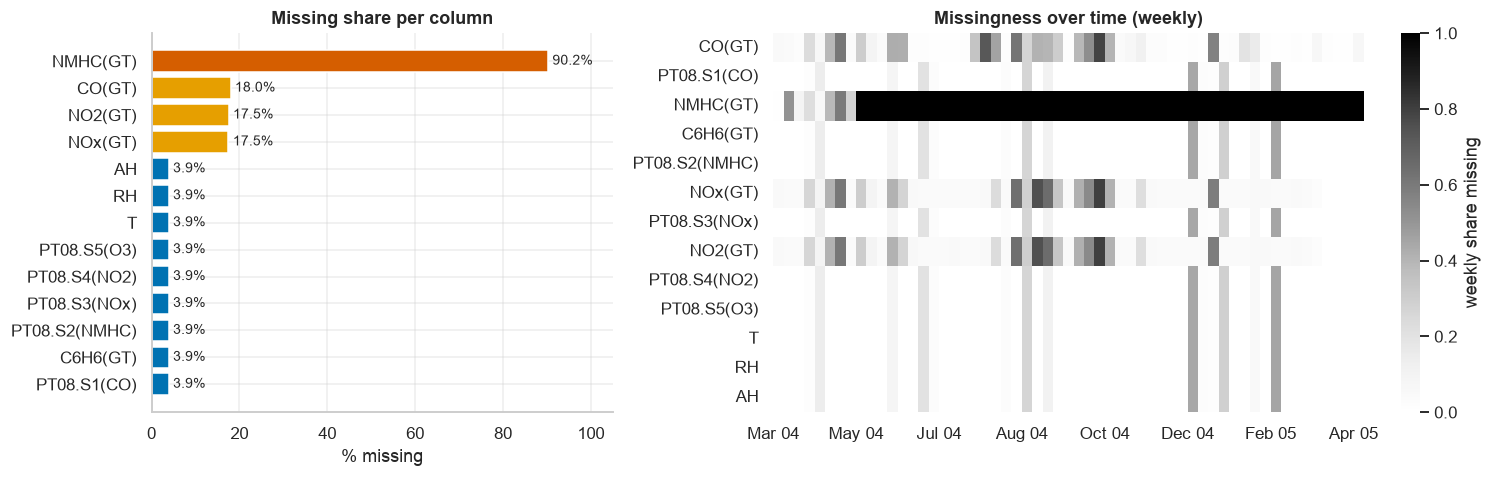

In [5]:
df = df.replace(-200, np.nan)

miss = pd.DataFrame({"missing": df.isna().sum(), "missing_%": df.isna().mean() * 100,
                     "valid": df.notna().sum()}).sort_values("missing_%", ascending=False)
display(miss.style.background_gradient(subset=["missing_%"], cmap="Oranges").format({"missing_%": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})
m = miss["missing_%"].sort_values()
axes[0].barh(m.index, m.values, color=[RED if v > 50 else ORANGE if v > 10 else BLUE for v in m.values])
for i, v in enumerate(m.values): axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_xlim(0, 105); axes[0].set_xlabel("% missing"); axes[0].set_title("Missing share per column")

# Missingness over time: one row per column, dark = missing
sns.heatmap(df.isna().T.astype(int).resample("D", axis=1).mean() if False else
            df.isna().astype(int).resample("W").mean().T, cmap="Greys", cbar_kws={"label": "weekly share missing"},
            ax=axes[1], xticklabels=False)
wk = df.isna().astype(int).resample("W").mean().index
axes[1].set_xticks(np.arange(0, len(wk), 8)); axes[1].set_xticklabels([d.strftime("%b %y") for d in wk[::8]], rotation=0)
axes[1].set_title("Missingness over time (weekly)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

Rows with ALL 8 sensor/weather features missing : 366
Rows with ANY   sensor/weather feature missing  : 366  -> partial-missing rows = 0
Rows where C6H6(GT) is missing ALSO have all features missing: True


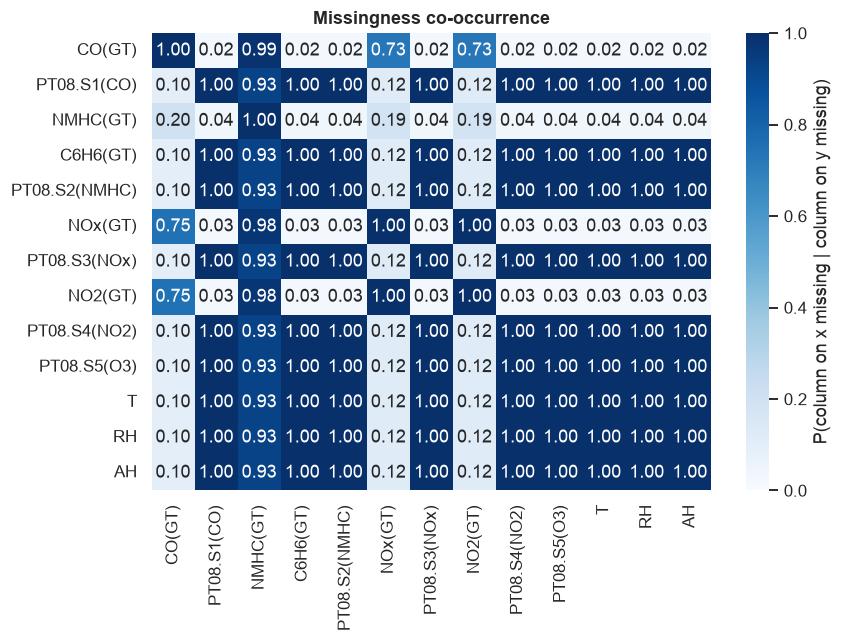


Longest consecutive outage (hours):
{'CO(GT)': 173, 'NOx(GT)': 173, 'NO2(GT)': 173, 'C6H6(GT)': 76, 'PT08.S1(CO)': 76}


In [6]:
# Is the missingness structured?  (a) rows where ALL sensors+weather are missing, (b) how GT-missingness overlaps
all_feat_missing = df[FEATURE_CANDIDATES].isna().all(axis=1)
any_feat_missing = df[FEATURE_CANDIDATES].isna().any(axis=1)
print(f"Rows with ALL 8 sensor/weather features missing : {all_feat_missing.sum()}")
print(f"Rows with ANY   sensor/weather feature missing  : {any_feat_missing.sum()}  "
      f"-> partial-missing rows = {(any_feat_missing & ~all_feat_missing).sum()}")
print(f"Rows where C6H6(GT) is missing ALSO have all features missing: "
      f"{(df['C6H6(GT)'].isna() == all_feat_missing).all()}")

# Missingness co-occurrence matrix (Jaccard-style: P(col B missing | col A missing))
M = df.isna().astype(int)
cooc = pd.DataFrame({b: {a: (M[a] & M[b]).sum() / max(M[a].sum(), 1) for a in M.columns} for b in M.columns})
plt.figure(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "P(column on x missing | column on y missing)"})
plt.title("Missingness co-occurrence"); plt.tight_layout(); plt.show()

# Longest consecutive outage of target candidates (hours)
def longest_run(s):
    g = s.ne(s.shift()).cumsum(); r = s.groupby(g).sum(); return int(r.max())
print("\nLongest consecutive outage (hours):")
print({c: longest_run(df[c].isna()) for c in ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "PT08.S1(CO)"]})

**Diagnosis**
- **NMHC(GT) is ~90 % missing** (only 914 valid hours). It is unusable as a target and cannot be imputed credibly → **excluded**.
- All five sensors, `T`, `RH`, `AH` and `C6H6(GT)` share the **same 366 missing hours**: whole rows are blank (instrument outages), there are *no* partially-missing feature rows. The missingness co-occurrence matrix confirms the block structure. There is nothing to impute for the features – those rows hold **zero** information and are dropped.
- `CO(GT)`, `NOx(GT)`, `NO2(GT)` are additionally missing for ~1.3–1.7 k hours (≈17–18 %), as the reference analyser was offline at times, often for long consecutive stretches (see the outage lengths above) — time-interpolating across multi-day gaps would fabricate data.
- **Never impute the target**: a regression label filled in by a heuristic makes the model learn the heuristic. Rows without a target are dropped.

### 1.5 Choosing the target variable

In [7]:
cand = pd.DataFrame(index=GT_COLS)
cand["valid_rows"] = df[GT_COLS].notna().sum()
cand["valid_%"] = df[GT_COLS].notna().mean() * 100
cand["usable_rows (target & features valid)"] = [(df[c].notna() & ~any_feat_missing).sum() for c in GT_COLS]
cand["skew"] = df[GT_COLS].skew()
# strongest single-sensor linear relation (|Pearson r|) and the sensor it comes from
best = {c: df[[c] + FEATURE_CANDIDATES].corr()[c].drop(c).abs().sort_values(ascending=False).head(1) for c in GT_COLS}
cand["best |r| with a feature"] = [best[c].iloc[0] for c in GT_COLS]
cand["... which feature"] = [best[c].index[0] for c in GT_COLS]
display(cand)

,valid_rows,valid_%,usable_rows (target & features valid),skew,best |r| with a feature,... which feature
CO(GT),7674,82.013,7344,1.370,0.916,PT08.S2(NMHC)
NMHC(GT),914,9.768,887,1.557,0.878,PT08.S2(NMHC)
C6H6(GT),8991,96.088,8991,1.362,0.982,PT08.S2(NMHC)
NOx(GT),7718,82.484,7396,1.716,0.787,PT08.S5(O3)
NO2(GT),7715,82.452,7393,0.622,0.708,PT08.S5(O3)


**Decision: target = `CO(GT)`** (true hourly CO concentration, mg/m³).

| Candidate | Verdict |
|---|---|
| `NMHC(GT)` | ~90 % missing → rejected. |
| `C6H6(GT)` | Most complete, but benzene in this dataset is almost a deterministic function of the `PT08.S2(NMHC)` sensor (|r| ≈ 0.98) — the task would be trivial and not discriminate between models. |
| `NOx(GT)` / `NO2(GT)` | Valid, but ~17 % missing and `NOx` is extremely right-skewed. |
| **`CO(GT)`** | ~7.7 k valid rows (plenty), has a **strong but imperfect** relation (|r| ≈ 0.9 with `PT08.S2`) with several sensors, a visible non-linear component, and a diurnal traffic signal — ideal for contrasting Linear/Polynomial regression with Decision Trees. |

Features are restricted to the **8 sensors + weather variables** as the brief specifies; the other GT pollutants are *not* used as predictors (they would be unavailable at inference time for a low-cost sensor and would leak the answer).

In [8]:
TARGET = "CO(GT)"
FEATURES = FEATURE_CANDIDATES.copy()
print("Target  :", TARGET)
print("Features:", FEATURES)

# Drop: (i) rows with no sensor/weather readings, (ii) rows with no target.  -> Never impute the target.
data = df[FEATURES + [TARGET]].dropna()
flow = pd.DataFrame({"step": ["Raw rows after structural cleaning", "- rows with all features missing (sensor outage)",
                              f"- rows with missing target {TARGET}", "= Modelling dataset"],
                     "rows": [len(df), -int(any_feat_missing.sum()),
                              -int((df[FEATURES].notna().all(axis=1) & df[TARGET].isna()).sum()), len(data)]})
display(flow)
assert data.isna().sum().sum() == 0
print(f"Retained {len(data)/len(df):.1%} of hourly records; remaining NaNs: {int(data.isna().sum().sum())}")

Target  : CO(GT)
Features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,step,rows
0,Raw rows after structural cleaning,9357
1,- rows with all features missing (sensor outage),-366
2,- rows with missing target CO(GT),-1647
3,= Modelling dataset,7344


Retained 78.5% of hourly records; remaining NaNs: 0


### 1.6 Target analysis — `CO(GT)`: distribution, class-wise balance

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis,CV (std/mean)
CO(GT),"7,344.000",2.130,1.436,0.100,0.200,0.500,1.100,1.800,2.800,4.900,6.700,11.900,1.357,2.658,0.674


Distinct target values: 94 | smallest step: 0.1


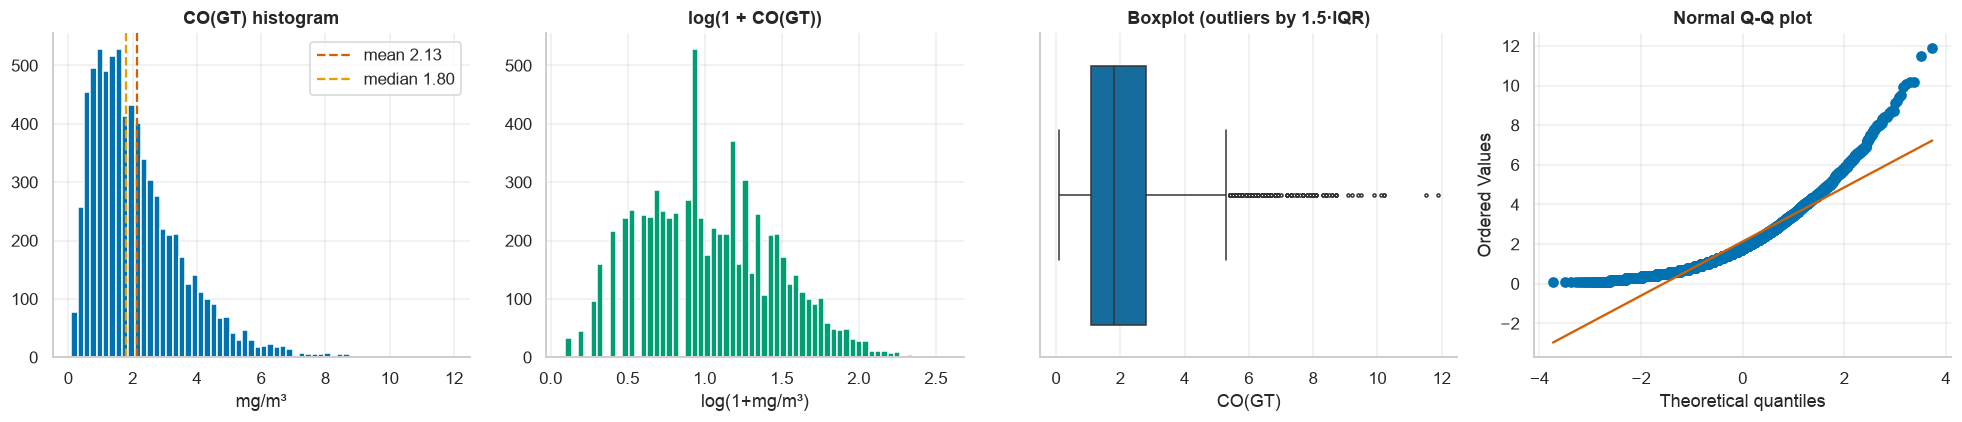

Shapiro-Wilk (5k sample): W=0.901, p=5.4e-49 -> normality rejected; skew 1.36 -> log-transform skew 0.22


In [9]:
y = data[TARGET]
desc = y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("CO(GT)").T
desc["skew"], desc["kurtosis"] = y.skew(), y.kurt()
desc["CV (std/mean)"] = y.std() / y.mean()
display(desc)

# Resolution of the label: CO is reported in 0.1 mg/m3 steps
print("Distinct target values:", y.nunique(), "| smallest step:", np.diff(np.sort(y.unique())).min().round(2))

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].hist(y, bins=60, color=BLUE, edgecolor="white"); ax[0].axvline(y.mean(), color=RED, ls="--", label=f"mean {y.mean():.2f}")
ax[0].axvline(y.median(), color=ORANGE, ls="--", label=f"median {y.median():.2f}"); ax[0].legend(); ax[0].set_title("CO(GT) histogram"); ax[0].set_xlabel("mg/m³")
ax[1].hist(np.log1p(y), bins=60, color=GREEN, edgecolor="white"); ax[1].set_title("log(1 + CO(GT))"); ax[1].set_xlabel("log(1+mg/m³)")
sns.boxplot(x=y, ax=ax[2], color=BLUE, fliersize=2); ax[2].set_title("Boxplot (outliers by 1.5·IQR)")
stats.probplot(y, dist="norm", plot=ax[3]); ax[3].set_title("Normal Q-Q plot")
ax[3].get_lines()[0].set_color(BLUE); ax[3].get_lines()[1].set_color(RED)
plt.tight_layout(); plt.show()
sh_stat, sh_p = stats.shapiro(y.sample(5000, random_state=SEED))
print(f"Shapiro-Wilk (5k sample): W={sh_stat:.3f}, p={sh_p:.1e} -> normality {'rejected' if sh_p < .05 else 'not rejected'}; "
      f"skew {y.skew():.2f} -> log-transform skew {np.log1p(y).skew():.2f}")

**Observations.** `CO(GT)` is **right-skewed** (skew ≈ 1.3, long tail up to ~12 mg/m³ with a few high-pollution episodes); mean > median; Shapiro-Wilk rejects normality; the Q-Q plot bends upward at the upper tail. The values are quantised in 0.1 mg/m³ steps.
Implications: MSE/RMSE will be dominated by the rare high-concentration hours, and a plain linear fit will tend to under-predict the peaks. We keep the target in **original units** so the reported RMSE is physically interpretable (mg/m³) and comparable across all models; a log-transform is noted as an optional experiment, not applied by default.

#### Class-wise balance
CO(GT) is a continuous target, so "classes" are defined by binning it into **air-quality regimes**. We use the quartile bins (equal-count, to check how the split is balanced) and the EU/WHO-motivated bands (8-h limit of ~10 mg/m³ is hit only extremely rarely, so we use practical bands: *Low < 1.5, Moderate 1.5–3, High 3–5, Very high ≥ 5 mg/m³*).

,count,share_%,mean_CO,std_CO
CO(GT),,,,
Low (<1.5),2820,38.399,0.884,0.341
Moderate (1.5-3),2808,38.235,2.102,0.423
High (3-5),1369,18.641,3.740,0.548
Very high (>=5),347,4.725,6.124,1.141


Imbalance ratio (largest : smallest regime) = 8.1 : 1
Quartile bins: {Interval(0.099, 1.1, closed='right'): 2064, Interval(1.1, 1.8, closed='right'): 1698, Interval(1.8, 2.8, closed='right'): 1753, Interval(2.8, 11.9, closed='right'): 1829}


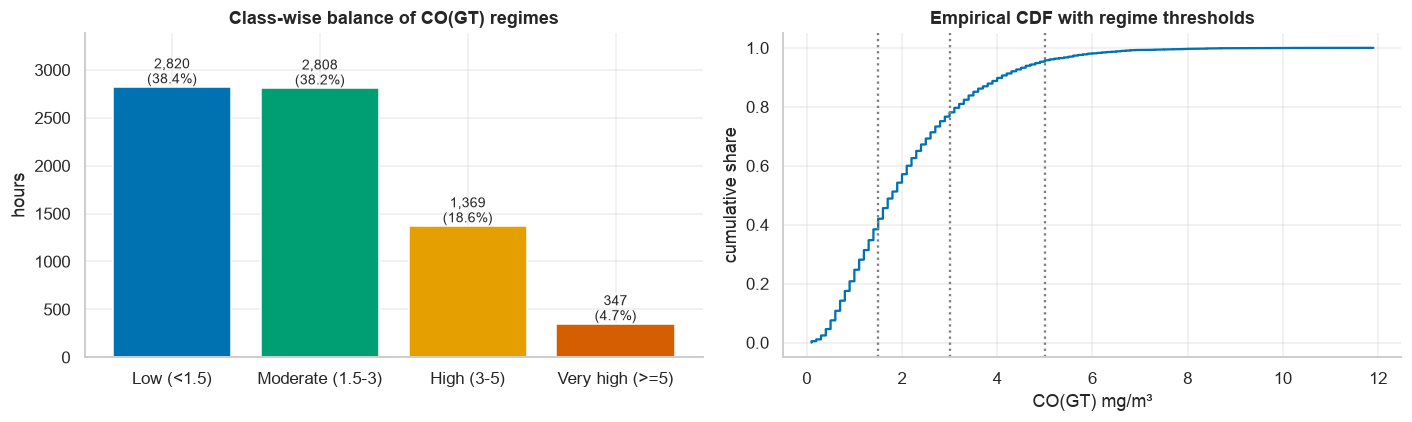

In [10]:
bands_edges  = [0, 1.5, 3, 5, np.inf]
bands_labels = ["Low (<1.5)", "Moderate (1.5-3)", "High (3-5)", "Very high (>=5)"]
band = pd.cut(y, bins=bands_edges, labels=bands_labels, right=False)
quart = pd.qcut(y, 4, duplicates="drop")

bal = pd.DataFrame({"count": band.value_counts().sort_index()})
bal["share_%"] = bal["count"] / bal["count"].sum() * 100
bal["mean_CO"] = y.groupby(band).mean(); bal["std_CO"] = y.groupby(band).std()
display(bal)
imbalance_ratio = bal["count"].max() / bal["count"].min()
print(f"Imbalance ratio (largest : smallest regime) = {imbalance_ratio:.1f} : 1")
print("Quartile bins:", quart.value_counts().sort_index().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
colors = [BLUE, GREEN, ORANGE, RED]
ax[0].bar(bal.index, bal["count"], color=colors)
for i, (c, s) in enumerate(zip(bal["count"], bal["share_%"])): ax[0].text(i, c + 40, f"{c:,}\n({s:.1f}%)", ha="center", fontsize=9)
ax[0].set_ylim(0, bal["count"].max() * 1.2); ax[0].set_title("Class-wise balance of CO(GT) regimes"); ax[0].set_ylabel("hours")
ecdf = np.sort(y); ax[1].plot(ecdf, np.arange(1, len(ecdf) + 1) / len(ecdf), color=BLUE)
for e in bands_edges[1:-1]: ax[1].axvline(e, color=GREY, ls=":")
ax[1].set_title("Empirical CDF with regime thresholds"); ax[1].set_xlabel("CO(GT) mg/m³"); ax[1].set_ylabel("cumulative share")
plt.tight_layout(); plt.show()

**Diagnosis — imbalance.** The regimes are clearly **imbalanced**: most hours are *Low/Moderate* and only a few percent are *Very high*. For regression this matters in three ways:
1. A random split may by chance put too few extreme hours in the test set → unstable R². We therefore make the **80/20 split stratified on these regime bins**, so train and test have the same target distribution (verified in §1.12).
2. Error metrics are dominated by the rare high values; we will also report errors **per regime** during evaluation (Stage 3).
3. We do **not** re-sample/oversample (that is a classification remedy and would distort the continuous target); stratification is the appropriate control.

### 1.7 Feature analysis — distributions & descriptive statistics

In [11]:
X = data[FEATURES]
fs = X.describe(percentiles=[.01, .25, .5, .75, .99]).T
fs["skew"], fs["kurtosis"], fs["CV"] = X.skew(), X.kurt(), X.std() / X.mean()
fs["range"] = fs["max"] - fs["min"]
display(fs)
print("Scale mismatch: largest/smallest feature std =", f"{X.std().max() / X.std().min():,.0f}x",
      "| largest/smallest mean magnitude =", f"{X.mean().abs().max() / X.mean().abs().min():,.0f}x")

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis,CV,range
PT08.S1(CO),"7,344.000","1,110.581",218.681,647.000,746.000,946.000,"1,075.000","1,246.000","1,722.570","2,040.000",0.727,0.294,0.197,"1,393.000"
PT08.S2(NMHC),"7,344.000",947.198,265.472,387.000,471.430,743.000,919.000,"1,125.250","1,642.140","2,214.000",0.532,0.033,0.280,"1,827.000"
PT08.S3(NOx),"7,344.000",826.920,256.648,322.000,401.000,649.000,795.000,960.000,"1,664.570","2,683.000",1.152,2.917,0.310,"2,361.000"
PT08.S4(NO2),"7,344.000","1,444.753",350.344,551.000,742.000,"1,203.000","1,447.000","1,673.000","2,342.420","2,775.000",0.219,-0.031,0.242,"2,224.000"
PT08.S5(O3),"7,344.000","1,043.513",405.570,221.000,347.000,744.750,990.000,"1,305.000","2,109.140","2,523.000",0.577,0.003,0.389,"2,302.000"
T,"7,344.000",17.770,8.863,-1.900,2.043,11.200,16.900,23.800,39.300,44.600,0.377,-0.417,0.499,46.500
RH,"7,344.000",49.060,17.452,9.200,14.800,35.400,49.300,62.500,83.057,88.700,-0.015,-0.844,0.356,79.500
AH,"7,344.000",0.989,0.400,0.185,0.273,0.698,0.960,1.259,1.940,2.181,0.340,-0.460,0.404,1.996


Scale mismatch: largest/smallest feature std = 1,014x | largest/smallest mean magnitude = 1,460x


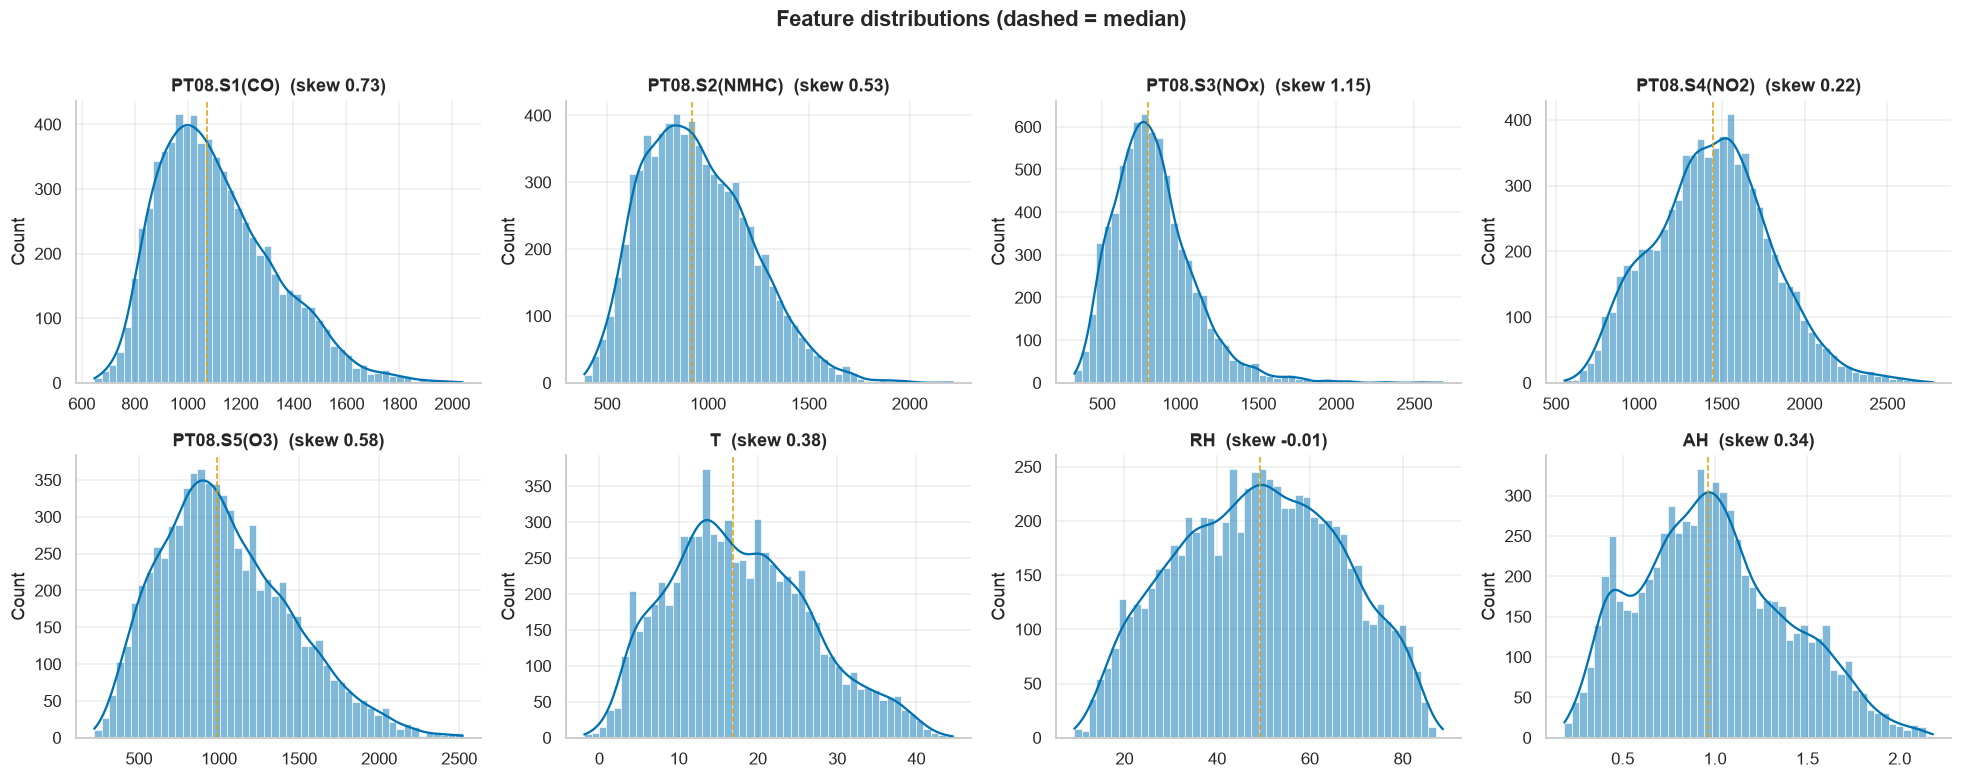

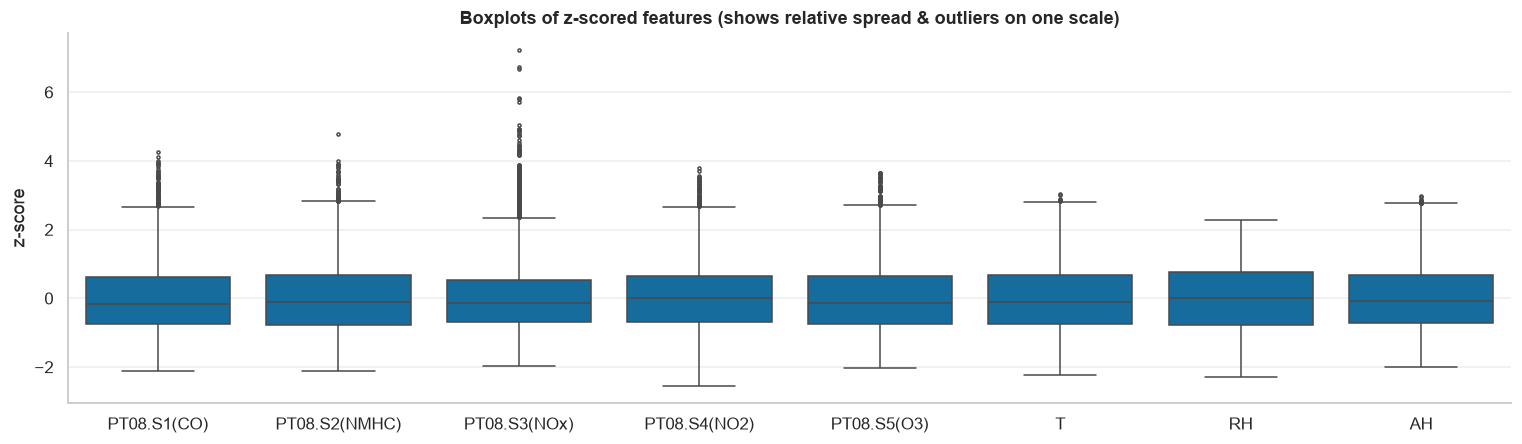

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(axes.ravel(), FEATURES):
    sns.histplot(X[c], bins=50, kde=True, color=BLUE, ax=a, edgecolor="white")
    a.axvline(X[c].median(), color=ORANGE, ls="--", lw=1); a.set_title(f"{c}  (skew {X[c].skew():.2f})"); a.set_xlabel("")
plt.suptitle("Feature distributions (dashed = median)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 4.2))
sns.boxplot(data=(X - X.mean()) / X.std(), orient="v", ax=ax, color=BLUE, fliersize=2)
ax.set_title("Boxplots of z-scored features (shows relative spread & outliers on one scale)"); ax.set_ylabel("z-score")
plt.tight_layout(); plt.show()

**Observations.**
- **Wildly different scales**: sensors are in the hundreds–thousands (≈ 200–2800), `T` ≈ −2…45 °C, `RH` ≈ 10–90 %, `AH` ≈ 0.2–2.2. Gradient-descent regression (Stage 2, "metric vs. epoch") and polynomial features need **standardisation**; otherwise the large-scale sensors dominate the gradient and the high-degree terms explode numerically. Decision Trees are scale-invariant, so they will be fed the same scaled data purely for a fair like-for-like comparison.
- `PT08.S3(NOx)` is clearly right-skewed with a long tail (skew ≈ 1.15, kurtosis ≈ 2.9); the other sensors are mildly skewed; `T`, `RH`, `AH` are broad and roughly symmetric (`RH` and `AH` platykurtic).
- No physically impossible values remain after the −200 treatment (checked below).

### 1.8 Outlier & validity audit

,IQR outliers (n),IQR outliers (%),|z|>3 (n),max |z|
PT08.S1(CO),90.000,1.225,46.000,4.250
PT08.S2(NMHC),47.000,0.640,29.000,4.772
PT08.S3(NOx),191.000,2.601,91.000,7.232
PT08.S4(NO2),65.000,0.885,29.000,3.797
PT08.S5(O3),65.000,0.885,27.000,3.648
T,6.000,0.082,1.000,3.027
RH,0.000,0.000,0.000,2.284
AH,18.000,0.245,0.000,2.979
CO(GT),257.000,3.499,98.000,6.802


,passes
CO(GT) >= 0,True
"RH within [0,100]",True
AH > 0,True
sensor signals > 0,True
T in plausible range (-10..50 C),True


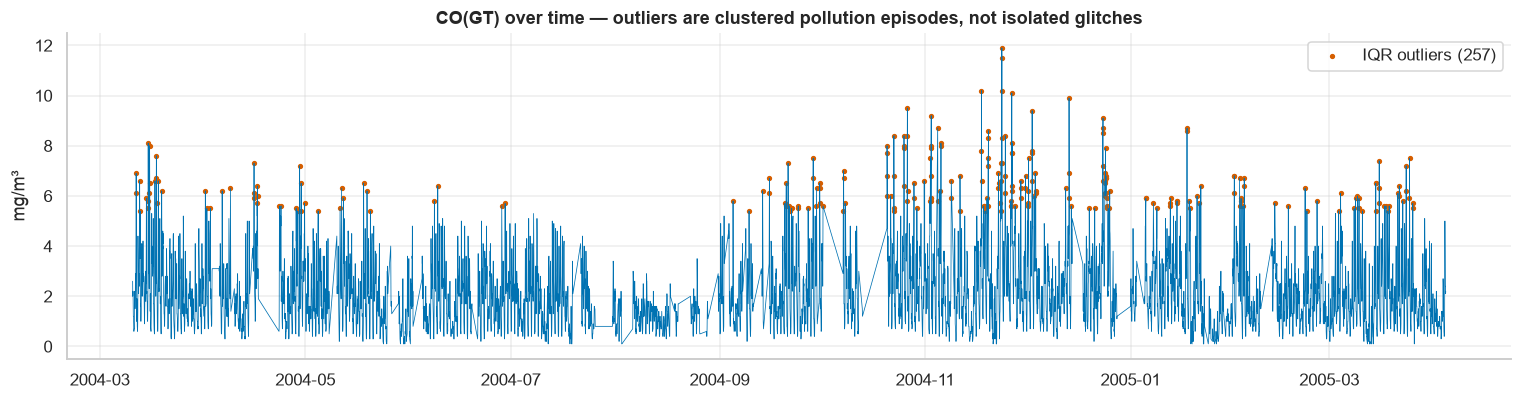

In [13]:
Z = (X - X.mean()) / X.std()
q1, q3 = X.quantile(.25), X.quantile(.75); iqr = q3 - q1
out = pd.DataFrame({
    "IQR outliers (n)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum(),
    "IQR outliers (%)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).mean() * 100,
    "|z|>3 (n)": (Z.abs() > 3).sum(),
    "max |z|": Z.abs().max()})
yq1, yq3 = y.quantile([.25, .75]); yi = yq3 - yq1
out.loc[TARGET] = [int(((y < yq1 - 1.5*yi) | (y > yq3 + 1.5*yi)).sum()), ((y < yq1 - 1.5*yi) | (y > yq3 + 1.5*yi)).mean()*100,
                   int((((y - y.mean()) / y.std()).abs() > 3).sum()), ((y - y.mean()) / y.std()).abs().max()]
display(out)

# Physical-validity checks
checks = {"CO(GT) >= 0": (y >= 0).all(), "RH within [0,100]": X["RH"].between(0, 100).all(),
          "AH > 0": (X["AH"] > 0).all(), "sensor signals > 0": (X[SENSOR_COLS] > 0).all().all(),
          "T in plausible range (-10..50 C)": X["T"].between(-10, 50).all()}
display(pd.Series(checks, name="passes").to_frame())

# Are the outliers real events or glitches?  Look at the extreme hours in time.
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(y.index, y, lw=.5, color=BLUE); hi = y[y > yq3 + 1.5 * yi]
ax.scatter(hi.index, hi, s=6, color=RED, label=f"IQR outliers ({len(hi)})")
ax.set_title("CO(GT) over time — outliers are clustered pollution episodes, not isolated glitches"); ax.set_ylabel("mg/m³"); ax.legend()
plt.tight_layout(); plt.show()

**Decision — keep the outliers.** They are not random sensor glitches: ~70 % of the flagged CO hours have another flagged hour right next to them (contiguous *episodes*), and they concentrate in the **morning (08–09 h) and evening (17–20 h) rush hours**, consistent with traffic emissions and with high sensor readings. Removing them would delete exactly the hours a pollution model should learn to predict, and make the test score optimistic. Standardisation (mean/std) is sensitive to outliers but, since none are impossible values, it is retained; no clipping/winsorising is applied.

### 1.9 Relationships — correlations, linearity, multicollinearity

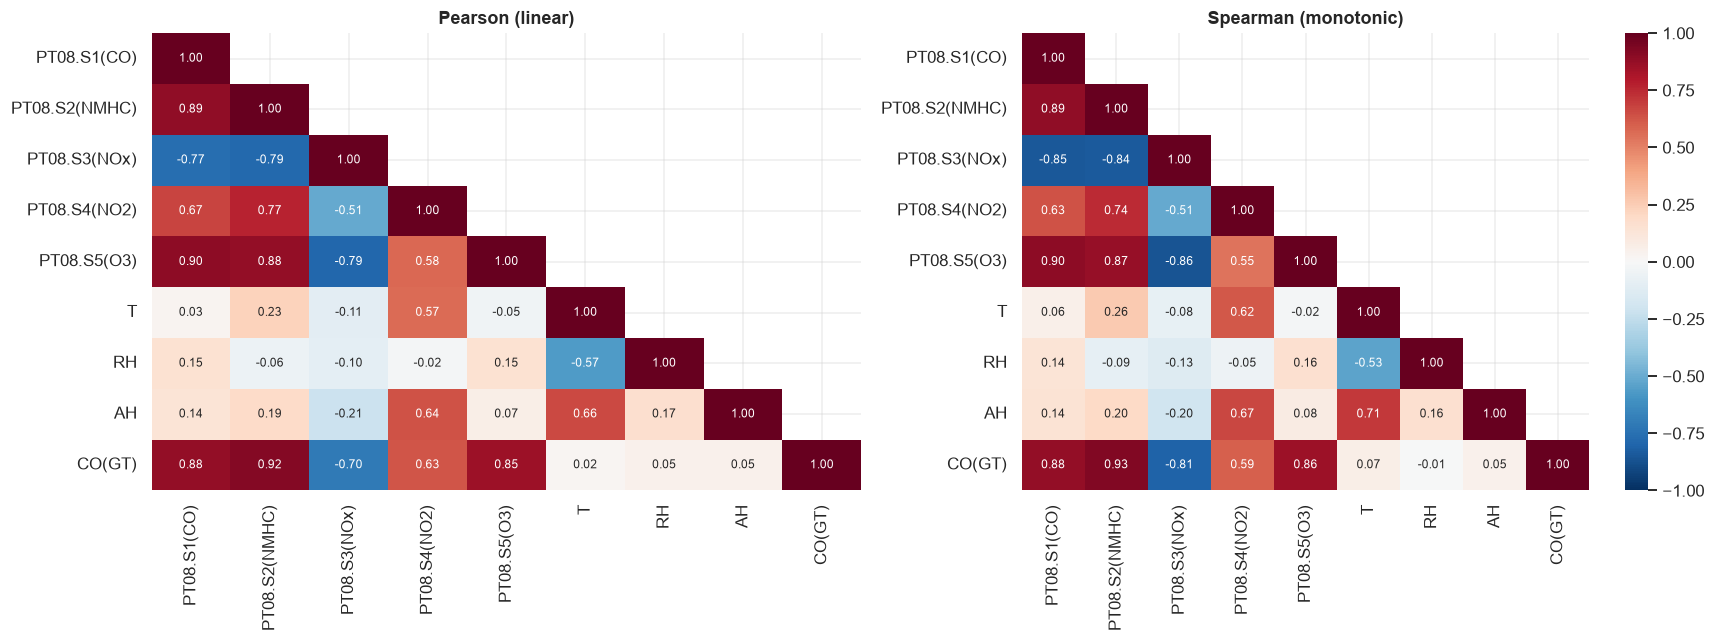

,Pearson r,Spearman rho,|gap|
PT08.S2(NMHC),0.916,0.927,0.011
PT08.S1(CO),0.879,0.879,0.000
PT08.S5(O3),0.854,0.856,0.002
PT08.S3(NOx),-0.703,-0.811,0.108
PT08.S4(NO2),0.631,0.594,-0.036
RH,0.049,-0.006,-0.042
AH,0.049,0.053,0.005
T,0.022,0.069,0.047


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
corr_p = data.corr(method="pearson"); corr_s = data.corr(method="spearman")
mask = np.triu(np.ones_like(corr_p, dtype=bool), k=1)
sns.heatmap(corr_p, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[0], cbar=False, annot_kws={"size": 8})
ax[0].set_title("Pearson (linear)")
sns.heatmap(corr_s, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[1], annot_kws={"size": 8})
ax[1].set_title("Spearman (monotonic)"); plt.tight_layout(); plt.show()

rel = pd.DataFrame({"Pearson r": corr_p[TARGET], "Spearman rho": corr_s[TARGET]}).drop(TARGET)
rel["|gap|"] = (rel["Spearman rho"].abs() - rel["Pearson r"].abs())
display(rel.sort_values("Pearson r", key=abs, ascending=False))

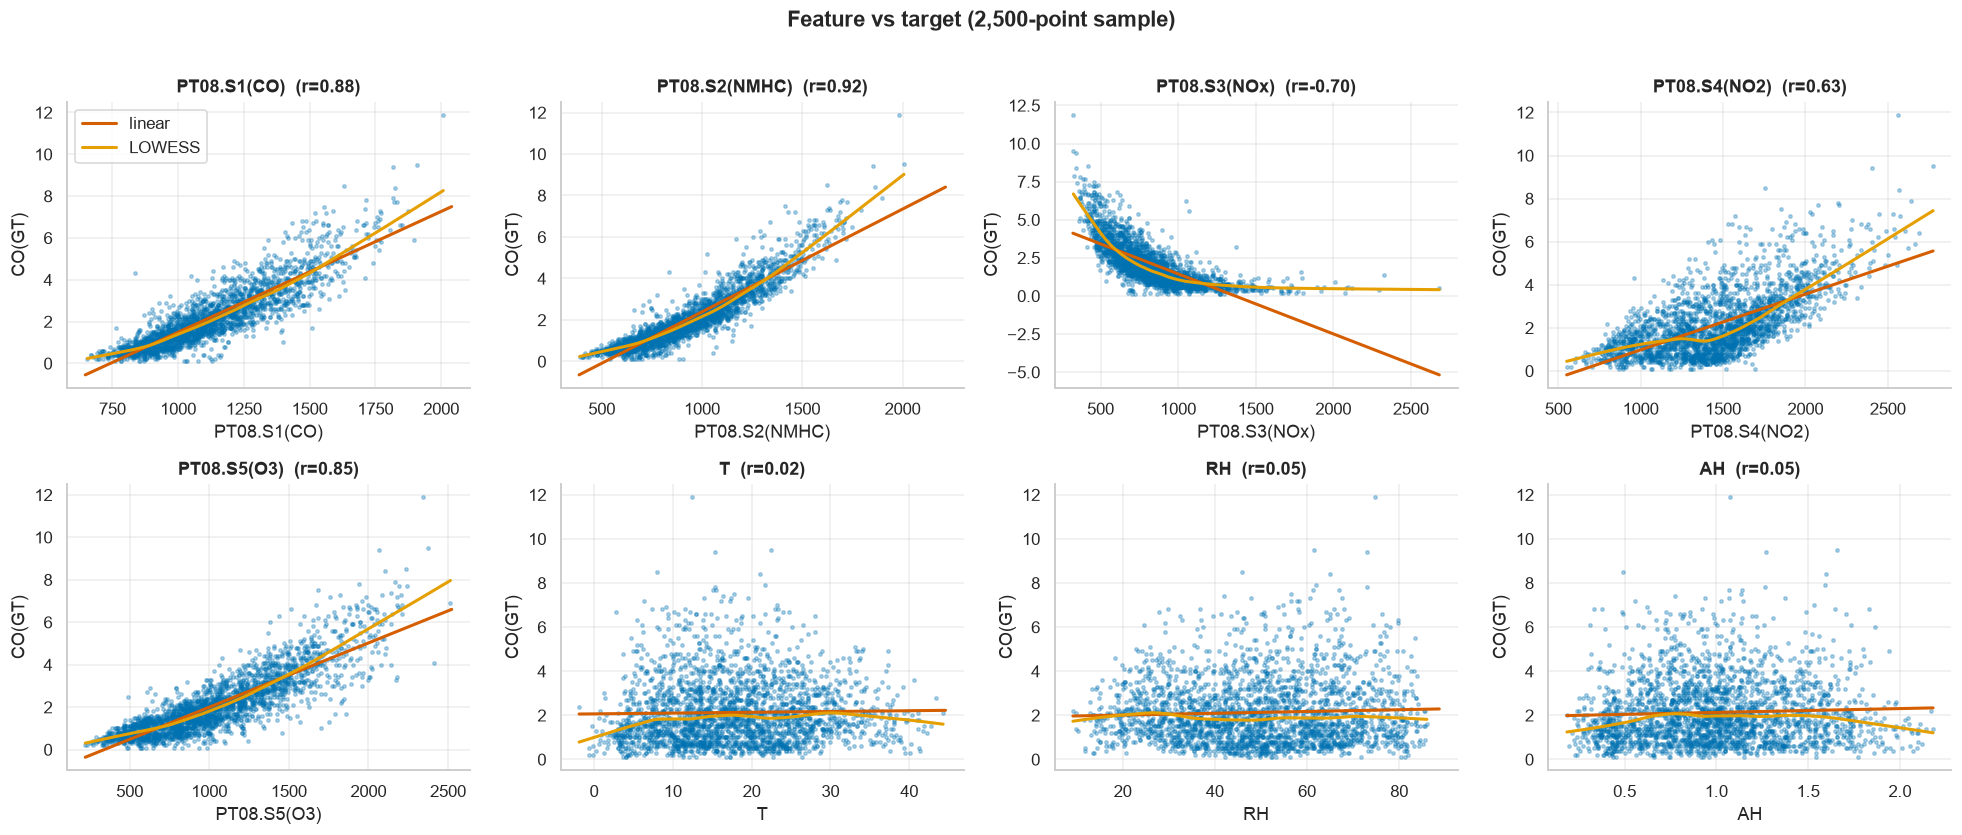

In [15]:
# Scatter of each feature vs target with linear (red) and LOWESS (orange) fits -> reveals non-linearity
from statsmodels.nonparametric.smoothers_lowess import lowess
fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
samp = data.sample(2500, random_state=SEED)
for a, c in zip(axes.ravel(), FEATURES):
    a.scatter(samp[c], samp[TARGET], s=5, alpha=.3, color=BLUE)
    b = np.polyfit(data[c], y, 1); xs = np.linspace(data[c].min(), data[c].max(), 100)
    a.plot(xs, np.polyval(b, xs), color=RED, lw=2, label="linear")
    lw = lowess(samp[TARGET], samp[c], frac=.3); a.plot(lw[:, 0], lw[:, 1], color=ORANGE, lw=2, label="LOWESS")
    a.set_title(f"{c}  (r={corr_p.loc[c, TARGET]:.2f})"); a.set_xlabel(c); a.set_ylabel("CO(GT)")
axes[0, 0].legend(); plt.suptitle("Feature vs target (2,500-point sample)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

,VIF
PT08.S2(NMHC),15.2
T,13.6
PT08.S4(NO2),10.3
AH,10.0
PT08.S5(O3),8.2
PT08.S1(CO),8.1
RH,7.6
PT08.S3(NOx),4.1


Condition number (standardised X): 10.8


r
PT08.S1(CO)   PT08.S5(O3)    0.898
              PT08.S2(NMHC)  0.888
PT08.S2(NMHC) PT08.S5(O3)    0.877
PT08.S3(NOx)  PT08.S5(O3)   -0.794
PT08.S2(NMHC) PT08.S3(NOx)  -0.785
              PT08.S4(NO2)   0.772

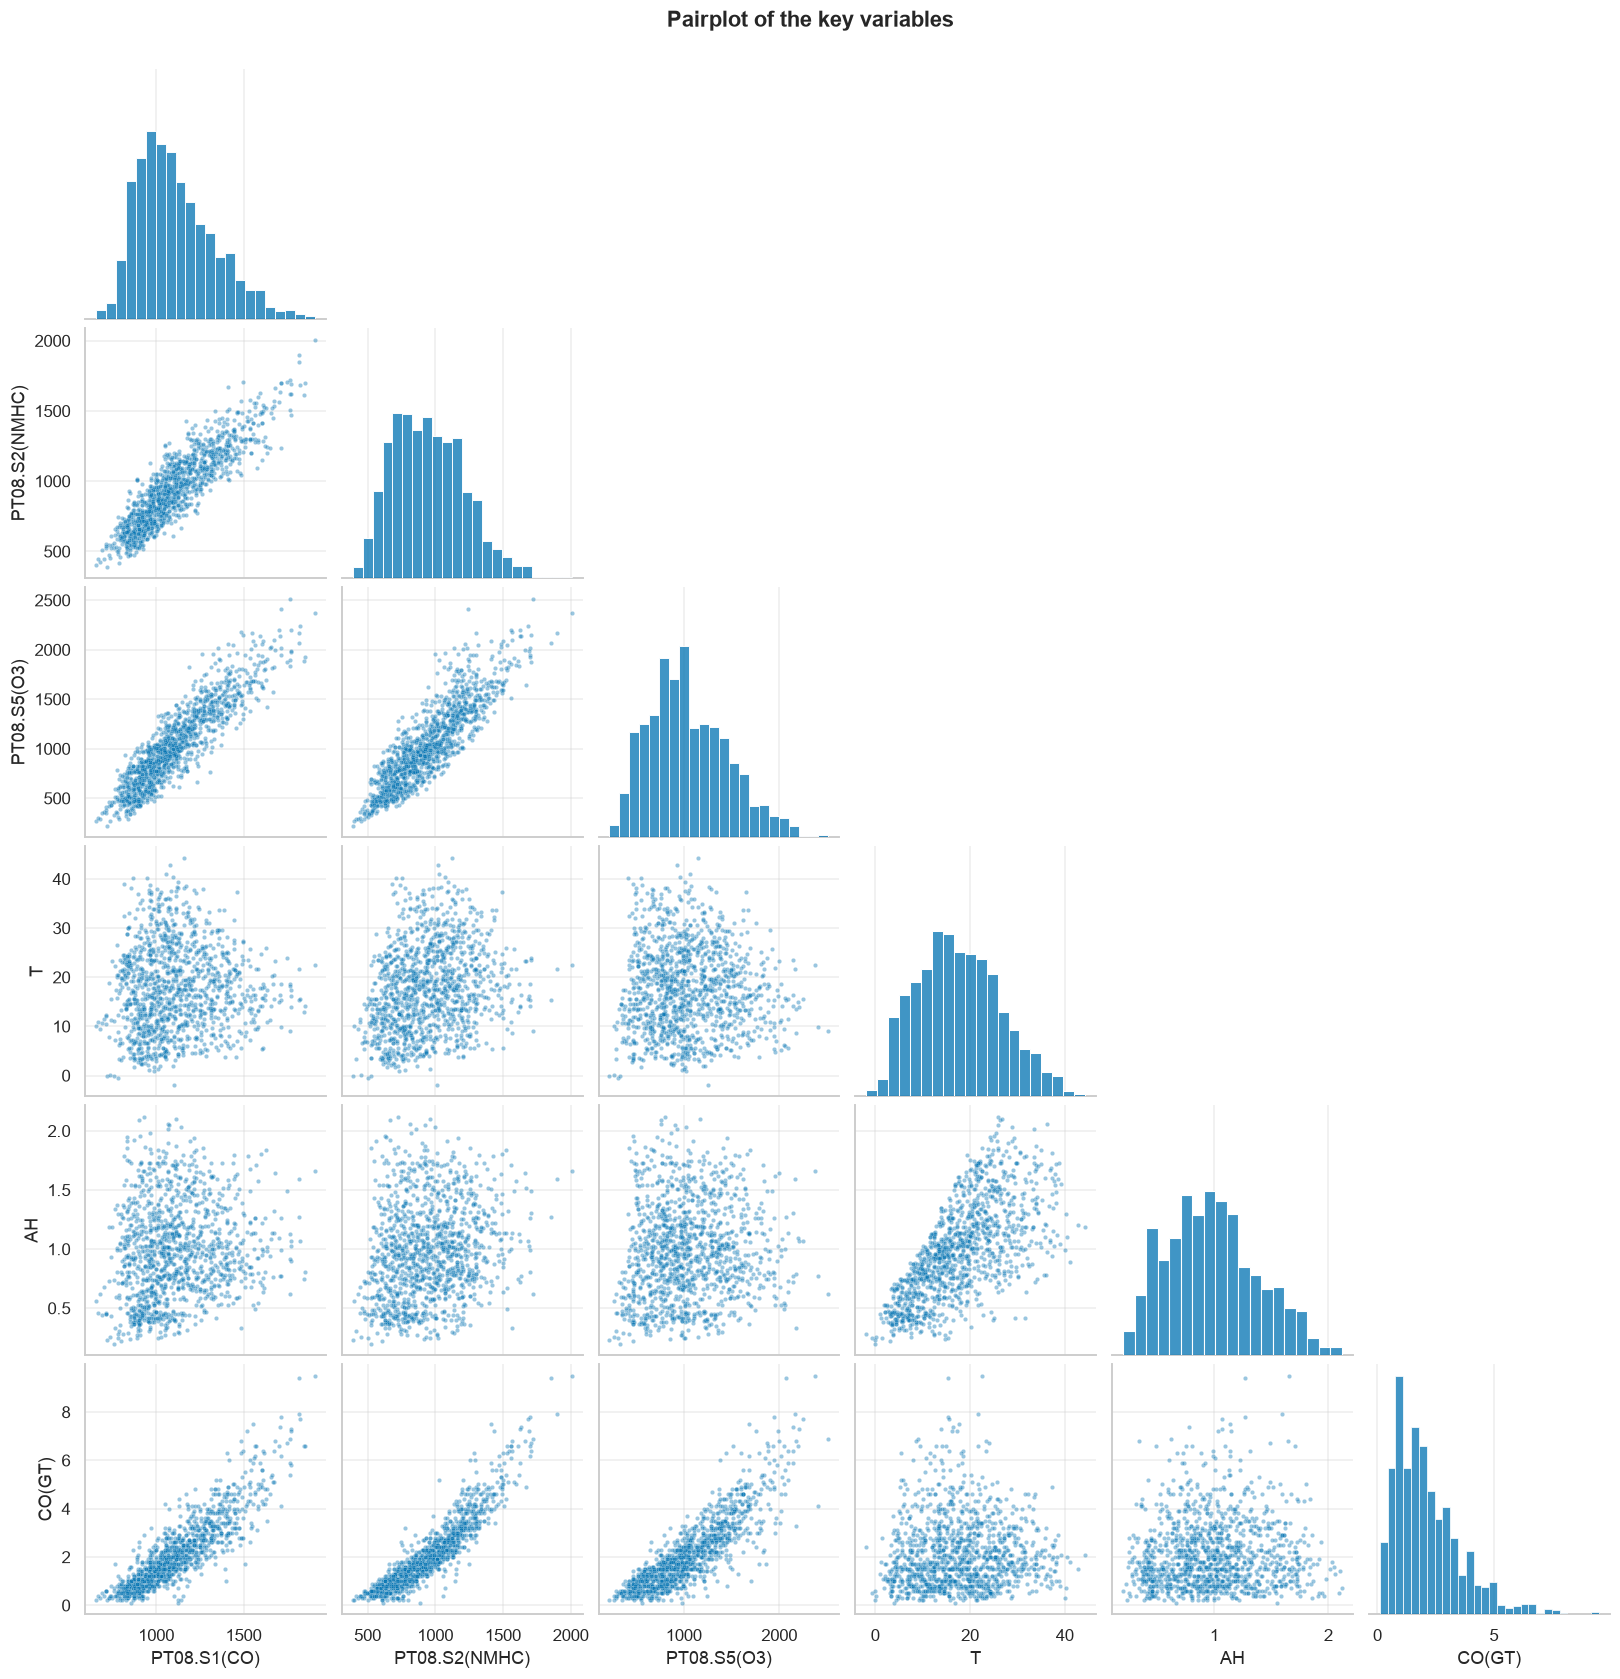

In [16]:
# Multicollinearity: VIF (>5 moderate, >10 severe) and condition number of the standardised feature matrix
Xs = (X - X.mean()) / X.std()
vif = pd.Series([variance_inflation_factor(Xs.values, i) for i in range(Xs.shape[1])], index=FEATURES, name="VIF").sort_values(ascending=False)
display(vif.to_frame().style.background_gradient(cmap="Reds").format("{:.1f}"))
print(f"Condition number (standardised X): {np.linalg.cond(Xs.values):.1f}")

# Most correlated feature pairs
pairs = corr_p.loc[FEATURES, FEATURES].where(np.triu(np.ones((8, 8), bool), 1)).stack().rename("r")
display(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6).to_frame())
sns.pairplot(samp[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S5(O3)", "T", "AH", TARGET]].sample(1200, random_state=SEED),
             corner=True, plot_kws={"s": 8, "alpha": .4, "color": BLUE}, diag_kws={"color": BLUE})
plt.suptitle("Pairplot of the key variables", y=1.02, fontweight="bold"); plt.show()

**Observations.**
- The CO target is most strongly related to **`PT08.S2(NMHC)`, `PT08.S1(CO)`, `PT08.S5(O3)`** (and negatively to `PT08.S3(NOx)`); the weather variables show weak linear association. `PT08.S3(NOx)` has |Spearman| ≈ 0.81 vs |Pearson| ≈ 0.70, i.e. a monotonic but clearly non-linear relation, and the LOWESS curves bend away from the straight line (see plots) → there is **some genuine non-linearity**, which motivates the polynomial and tree models.
- **Severe multicollinearity**: the CO, NMHC and O₃ sensors are strongly inter-correlated, `AH` is tied to `T`/`RH`, and four VIFs exceed 10 (`PT08.S2` ≈ 15, `T` ≈ 14, `PT08.S4` ≈ 10, `AH` ≈ 10; only `PT08.S3` is below 5), although the condition number of the standardised matrix is a moderate ≈ 11. Consequences for the next stages: (a) a degree-1 OLS fit is numerically fine after standardisation, but polynomial expansions will multiply the collinearity → use a stable `lstsq`/`pinv` solve or a small L2 term; (b) individual **linear coefficients will not be reliably interpretable**; (c) tree **feature importances will be split among correlated sensors** – interpret groups, not single features.
- All 8 features are kept: the assignment asks for sensors + weather, no feature is constant, and VIF-driven dropping would hurt tree performance for no benefit. Regularisation (Ridge) is *available* as a remedy if the polynomial fit proves unstable (decided in Stage 2 with validation data, not on the test set).

### 1.10 Temporal structure (seasonality, diurnal cycle, sensor drift)

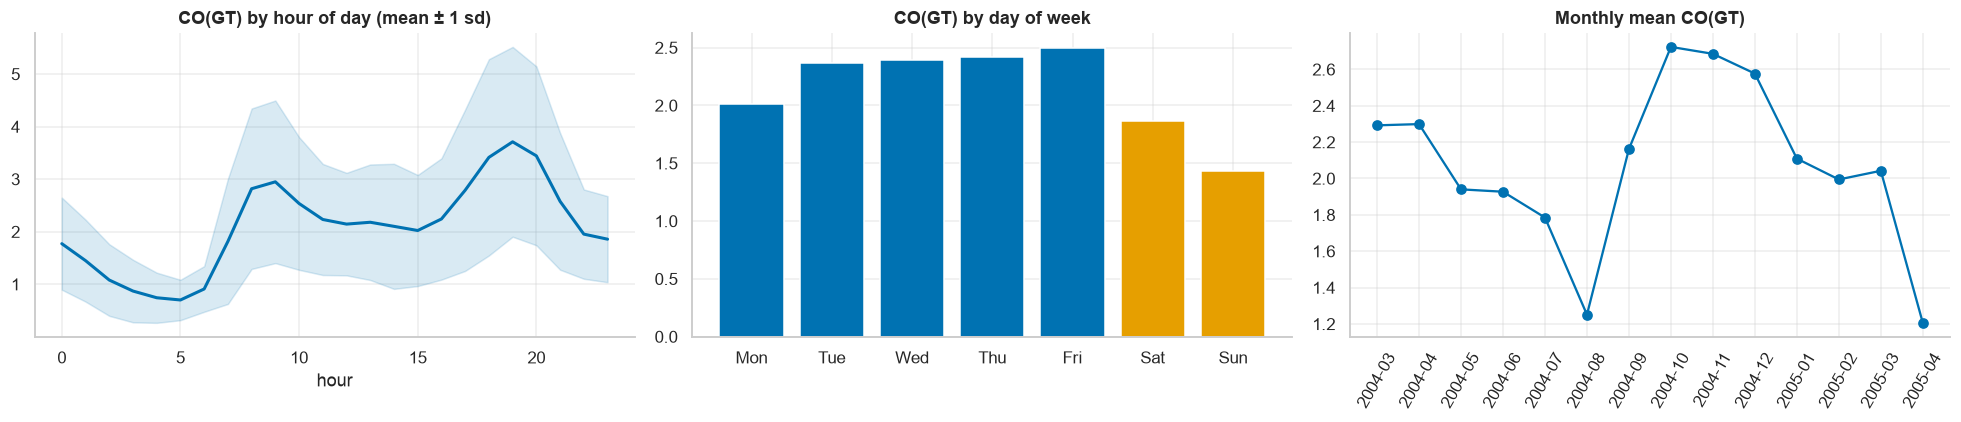

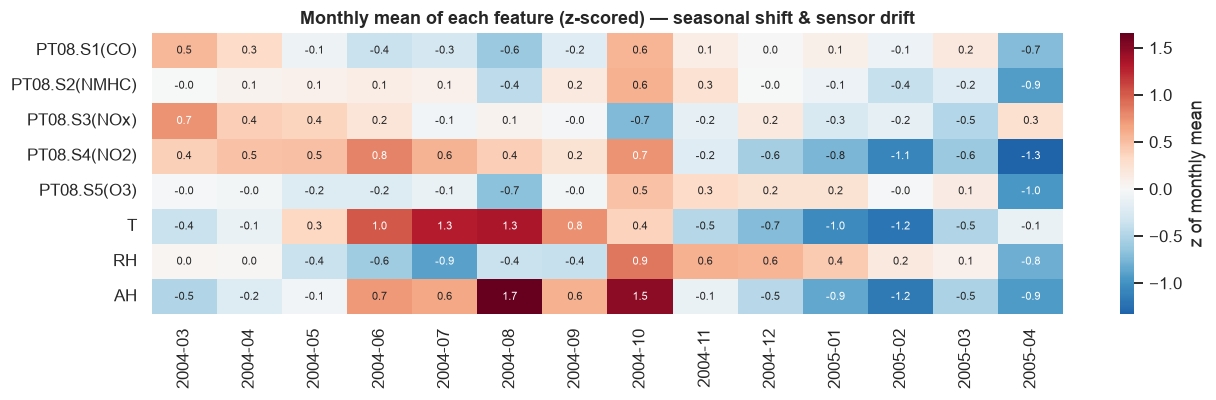

lag (h),1,2,3,6,12,24,48
autocorr,0.831,0.595,0.405,0.136,0.137,0.521,0.282


In [17]:
d = data.copy(); d["hour"] = d.index.hour; d["dow"] = d.index.dayofweek; d["month"] = d.index.to_period("M")
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
h = d.groupby("hour")[TARGET].agg(["mean", "std"]); ax[0].plot(h.index, h["mean"], color=BLUE, lw=2)
ax[0].fill_between(h.index, h["mean"] - h["std"], h["mean"] + h["std"], color=BLUE, alpha=.15); ax[0].set_title("CO(GT) by hour of day (mean ± 1 sd)"); ax[0].set_xlabel("hour")
wd = d.groupby("dow")[TARGET].mean(); ax[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], wd.values, color=[BLUE]*5 + [ORANGE]*2); ax[1].set_title("CO(GT) by day of week")
mo = d.groupby("month")[TARGET].mean(); ax[2].plot(mo.index.astype(str), mo.values, marker="o", color=BLUE); ax[2].set_title("Monthly mean CO(GT)"); ax[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

# Sensor drift / seasonal shift: monthly mean of each (z-scored) feature
mz = (d[FEATURES].groupby(d["month"]).mean() - X.mean()) / X.std()
plt.figure(figsize=(12, 3.8)); sns.heatmap(mz.T, cmap="RdBu_r", center=0, annot=True, fmt=".1f", annot_kws={"size": 7}, cbar_kws={"label": "z of monthly mean"})
plt.title("Monthly mean of each feature (z-scored) — seasonal shift & sensor drift"); plt.xlabel(""); plt.tight_layout(); plt.show()

# Autocorrelation of the target: how dependent are neighbouring hours?
ac = [y.autocorr(l) for l in (1, 2, 3, 6, 12, 24, 48)]
display(pd.DataFrame({"lag (h)": (1, 2, 3, 6, 12, 24, 48), "autocorr": ac}).set_index("lag (h)").T)

**Observations.**
- Clear **diurnal cycle** (peaks ≈ 2.9 mg/m³ at 09 h and ≈ 3.7 at 19 h, night minimum ≈ 0.7 at 05 h) and a **weekend dip** (Sat ≈ 1.9, Sun ≈ 1.4 vs ≈ 2.4 on weekdays) → CO is traffic-driven. The brief restricts predictors to sensors + weather; the sensors implicitly carry the diurnal signal, so we do **not** add hour/day features (a possible extension).
- **Seasonality & drift**: monthly mean CO is highest in **Oct–Dec (≈ 2.6–2.7)** and lowest in **Aug (≈ 1.25, holiday period)**; `T` swings from ≈ 30 °C (Aug) to ≈ 7 °C (Feb). The `PT08.S4(NO2)` sensor mean falls steadily from ≈ 1,600–1,700 (spring/summer 2004) to ≈ 1,000–1,200 (winter 2005) — a mix of seasonal effect and metal-oxide sensor drift, which matters for any out-of-time evaluation.
- **Strong autocorrelation** (lag-1 ≈ 0.83, lag-24 ≈ 0.52): neighbouring hours are near duplicates. A *random* split therefore yields a test set interleaved with training hours (optimistic, "interpolation" scores), whereas a *chronological* split measures true forecasting/generalisation to a new season. Evaluated in §1.11.

### 1.11 Train/test split strategy — random vs. chronological

In [18]:
# What would a chronological 80/20 split look like?  (first 80% of time -> train, last 20% -> test)
cut = int(len(data) * .8); tr_t, te_t = data.iloc[:cut], data.iloc[cut:]
print(f"Chronological split: train {tr_t.index.min():%d %b %Y} -> {tr_t.index.max():%d %b %Y} | test {te_t.index.min():%d %b %Y} -> {te_t.index.max():%d %b %Y}")
cmp = pd.DataFrame({"train mean": tr_t[FEATURES + [TARGET]].mean(), "test mean": te_t[FEATURES + [TARGET]].mean()})
cmp["shift (in train std)"] = (cmp["test mean"] - cmp["train mean"]) / tr_t[FEATURES + [TARGET]].std()
display(cmp)
ks = {c: stats.ks_2samp(tr_t[c], te_t[c]).statistic for c in FEATURES + [TARGET]}
print("KS statistic train-vs-test (chronological):", {k: round(v, 2) for k, v in ks.items()})

Chronological split: train 10 Mar 2004 -> 28 Jan 2005 | test 28 Jan 2005 -> 04 Apr 2005


,train mean,test mean,shift (in train std)
PT08.S1(CO),"1,112.152","1,104.295",-0.035
PT08.S2(NMHC),970.195,855.228,-0.433
PT08.S3(NOx),842.590,764.251,-0.300
PT08.S4(NO2),"1,523.574","1,129.521",-1.220
PT08.S5(O3),"1,047.547","1,027.378",-0.051
T,19.556,10.631,-1.049
RH,48.894,49.724,0.047
AH,1.076,0.645,-1.134
CO(GT),2.175,1.950,-0.154


KS statistic train-vs-test (chronological): {'PT08.S1(CO)': np.float64(0.04), 'PT08.S2(NMHC)': np.float64(0.2), 'PT08.S3(NOx)': np.float64(0.14), 'PT08.S4(NO2)': np.float64(0.53), 'PT08.S5(O3)': np.float64(0.07), 'T': np.float64(0.43), 'RH': np.float64(0.05), 'AH': np.float64(0.52), 'CO(GT)': np.float64(0.09)}


**Decision.** A chronological split trains on Mar 2004 – Jan 2005 (including the hot summer) and tests on the colder, drier late-Jan – Apr 2005 period, creating a large **covariate shift**: `T` −1.0 sd, `AH` −1.1 sd, `PT08.S4` −1.2 sd (KS statistics ≈ 0.4–0.5), while CO itself shifts only −0.15 sd. Such a test would mostly measure season extrapolation rather than model quality, and the polynomial/tree comparison the assignment asks for would be dominated by that shift.

The assignment simply specifies an **80/20 train/test split**, so we use a **shuffled, target-stratified 80/20 split** (`random_state=42`) as the primary protocol. We state its limitation openly: because of hourly autocorrelation, test scores will be somewhat optimistic relative to true forecasting. The chronological split above is kept as a documented *robustness check* option for the Discussion.

### 1.12 Final preprocessing: stratified 80/20 split → scaling (fit on train only)

In [19]:
X_all, y_all = data[FEATURES], data[TARGET]
strata = pd.cut(y_all, bins=bands_edges, labels=bands_labels, right=False)      # regimes from §1.6

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, shuffle=True, stratify=strata)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}  |  test share = {len(X_test)/len(X_all):.1%}")

# Standardisation: statistics learned ONLY from the training set (no test-set leakage), then applied to both
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES, index=X_test.index)

chk = pd.DataFrame({"train mean": X_train_s.mean(), "train std": X_train_s.std(ddof=0),
                    "test mean": X_test_s.mean(), "test std": X_test_s.std(ddof=0)})
display(chk)
assert np.allclose(X_train_s.mean(), 0, atol=1e-9) and np.allclose(X_train_s.std(ddof=0), 1)

Train: (5875, 8)  |  Test: (1469, 8)  |  test share = 20.0%


,train mean,train std,test mean,test std
PT08.S1(CO),-0.000,1.000,0.003,1.004
PT08.S2(NMHC),0.000,1.000,-0.023,0.980
PT08.S3(NOx),0.000,1.000,0.014,1.009
PT08.S4(NO2),-0.000,1.000,-0.004,0.985
PT08.S5(O3),0.000,1.000,-0.004,1.008
T,-0.000,1.000,0.011,1.018
RH,-0.000,1.000,-0.008,1.010
AH,-0.000,1.000,0.000,0.987


,train_n,test_n,train_%,test_%
CO(GT),,,,
Low (<1.5),2256,564,38.400,38.393
Moderate (1.5-3),2246,562,38.230,38.257
High (3-5),1095,274,18.638,18.652
Very high (>=5),278,69,4.732,4.697


,count,mean,std,min,25%,50%,75%,max
train,"5,875.000",2.132,1.440,0.100,1.100,1.800,2.850,11.900
test,"1,469.000",2.120,1.424,0.100,1.000,1.800,2.800,8.700


KS test on target train vs test: stat=0.015, p=0.94


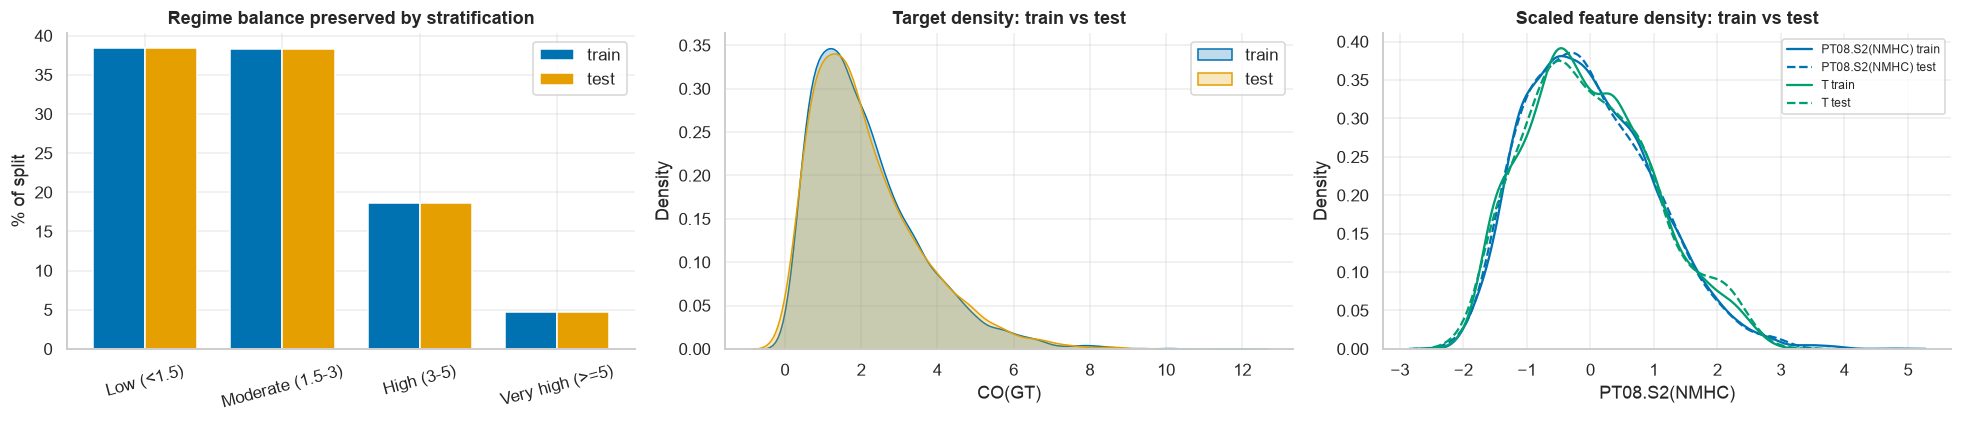

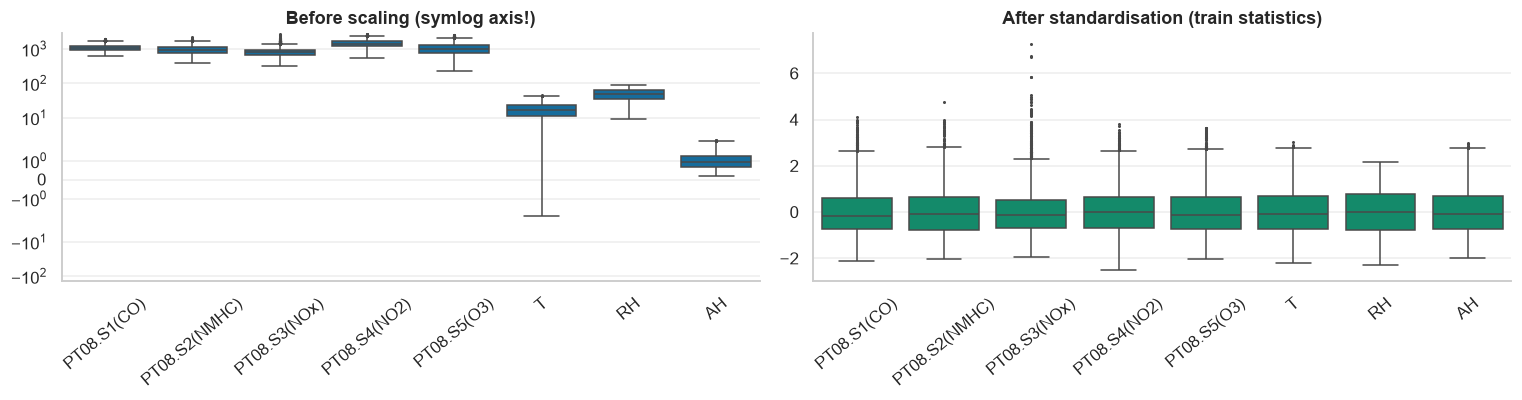

In [20]:
# Verify the split is representative: class balance, target distribution, feature distributions
sb = pd.DataFrame({"train_n": pd.cut(y_train, bands_edges, labels=bands_labels, right=False).value_counts().sort_index(),
                   "test_n":  pd.cut(y_test,  bands_edges, labels=bands_labels, right=False).value_counts().sort_index()})
sb["train_%"] = sb["train_n"] / sb["train_n"].sum() * 100; sb["test_%"] = sb["test_n"] / sb["test_n"].sum() * 100
display(sb)

tt = pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}); display(tt.T)
print(f"KS test on target train vs test: stat={stats.ks_2samp(y_train, y_test).statistic:.3f}, p={stats.ks_2samp(y_train, y_test).pvalue:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
w = .38; xi = np.arange(len(sb)); ax[0].bar(xi - w/2, sb["train_%"], w, color=BLUE, label="train"); ax[0].bar(xi + w/2, sb["test_%"], w, color=ORANGE, label="test")
ax[0].set_xticks(xi); ax[0].set_xticklabels(sb.index, rotation=15); ax[0].set_ylabel("% of split"); ax[0].set_title("Regime balance preserved by stratification"); ax[0].legend()
sns.kdeplot(y_train, ax=ax[1], color=BLUE, label="train", fill=True, alpha=.25); sns.kdeplot(y_test, ax=ax[1], color=ORANGE, label="test", fill=True, alpha=.25)
ax[1].set_title("Target density: train vs test"); ax[1].legend()
for c, col in zip(["PT08.S2(NMHC)", "T"], [BLUE, GREEN]):
    sns.kdeplot(X_train_s[c], ax=ax[2], color=col, label=f"{c} train"); sns.kdeplot(X_test_s[c], ax=ax[2], color=col, ls="--", label=f"{c} test")
ax[2].set_title("Scaled feature density: train vs test"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Scaling effect
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
sns.boxplot(data=X_train, ax=ax[0], color=BLUE, fliersize=1); ax[0].set_yscale("symlog"); ax[0].set_title("Before scaling (symlog axis!)"); ax[0].tick_params(axis="x", rotation=40)
sns.boxplot(data=X_train_s, ax=ax[1], color=GREEN, fliersize=1); ax[1].set_title("After standardisation (train statistics)"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

**Scaling / normalisation / regularisation plan — decisions made from the EDA**

| Aspect | Decision | Evidence from EDA |
|---|---|---|
| Missing sentinel | `-200 → NaN` | min = −200 in every column |
| Missing rows | drop outage rows & rows without target; **no imputation** | 366 whole-row outages; multi-day target gaps; target must not be imputed |
| Dropped column | `NMHC(GT)` | ~90 % missing |
| Target | `CO(GT)`, original units (mg/m³) | skewed but interpretable RMSE; log is an optional experiment |
| Feature scaling | **Z-score standardisation, fitted on train only** | scale mismatch of up to ~10³×; needed for gradient-descent "epochs" & polynomial terms; harmless for trees |
| Normalisation (min-max) | not used | outliers would squash the bulk of the data; z-score is preferred |
| Outliers | kept | real pollution episodes, no impossible values |
| Split | 80/20 shuffled, **stratified** on CO regimes, `seed=42` | class imbalance; stratification keeps test representative |
| Regularisation | none by default; **Ridge/L2 held in reserve** for polynomial regression; trees controlled via `max_depth` | VIF shows strong multicollinearity; high-degree polynomials may overfit |
| Polynomial degree | to be chosen by **validation/CV on the training set only** | non-linearity observed, but test set stays untouched |
| Hand-off to Stage 2 | `X_train_s, X_test_s, y_train, y_test, FEATURES, TARGET, scaler` | — |

In [21]:
# Final hand-off summary for the model-training stage
summary = pd.DataFrame({
    "object": ["X_train_s", "X_test_s", "y_train", "y_test"],
    "shape": [X_train_s.shape, X_test_s.shape, y_train.shape, y_test.shape],
    "NaNs": [int(X_train_s.isna().sum().sum()), int(X_test_s.isna().sum().sum()), int(y_train.isna().sum()), int(y_test.isna().sum())],
    "scaled": [True, True, False, False]}).set_index("object")
display(summary)
print("Features :", FEATURES); print("Target   :", TARGET, "(mg/m³)")
print("Index overlap train/test:", len(set(X_train.index) & set(X_test.index)), "(must be 0)")
assert len(set(X_train.index) & set(X_test.index)) == 0

,shape,NaNs,scaled
object,,,
X_train_s,"(5875, 8)",0,True
X_test_s,"(1469, 8)",0,True
y_train,"(5875,)",0,False
y_test,"(1469,)",0,False


Features : ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Target   : CO(GT) (mg/m³)
Index overlap train/test: 0 (must be 0)


✅ **Stage 1 complete.** The data are cleaned, the target and features are fixed, the scaler is fitted on the training data only, and the stratified train/test split is verified.

---
## Stage 2 — Model Training

**Design principles carried over from Stage 1**

| Stage 1 finding | Consequence for training |
|---|---|
| Hourly data are strongly autocorrelated (lag-1 ≈ 0.83) | Hyper-parameters (polynomial degree, learning rate, tree depth) are chosen with **group-aware 5-fold CV on the training set** (whole calendar weeks are kept together), never on the test set. |
| Features are collinear (VIF > 10) | Ridge (L2) is studied as an ablation for the polynomial model; coefficients are reported with bootstrap CIs. |
| Features differ ~10³× in scale | Gradient descent is run on standardised inputs; an ablation demonstrates why. |
| CO is right-skewed, ~8:1 regime imbalance | Besides MSE/RMSE/R² we also store residuals and **per-regime errors**; log-target is tested as an ablation. |
| Shuffled split is optimistic | An **out-of-time** (chronological) robustness check is run for the final models. |

**What this stage produces for later stages** (all kept in memory): the model registry `RESULTS`, fitted models `FITTED`, train/test predictions `PRED`, per-epoch histories `HISTORY`, the tree depth sweep `TREE_SWEEP`, feature-importance tables, learning curves and all ablation tables.

### 2.0 Setup, from-scratch metrics and the model registry

In [22]:
import time
from itertools import combinations_with_replacement
import matplotlib
import sklearn
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GroupKFold, cross_validate, learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

print({m.__name__: m.__version__ for m in (np, pd, sklearn)})

# ---- evaluation metrics implemented from scratch (verified against sklearn below) ----
def mse(y_true, y_pred):  return float(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2))
def rmse(y_true, y_pred): return float(np.sqrt(mse(y_true, y_pred)))
def mae(y_true, y_pred):  return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))
def r2(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))
def regression_metrics(y_true, y_pred):
    return {"mse": mse(y_true, y_pred), "rmse": rmse(y_true, y_pred), "r2": r2(y_true, y_pred), "mae": mae(y_true, y_pred)}

_a, _b = y_test.values, y_test.values * 0.9 + 0.1
assert np.isclose(mse(_a, _b), mean_squared_error(_a, _b)) and np.isclose(r2(_a, _b), r2_score(_a, _b)) and np.isclose(mae(_a, _b), mean_absolute_error(_a, _b))
print("From-scratch MSE / RMSE / R² / MAE match sklearn.metrics ✔")

# ---- registries shared with Stages 3-6 ----
RESULTS, FITTED, PRED, HISTORY = {}, {}, {}, {}

def timed_fit(model, X, y, **kw):
    t = time.perf_counter(); model.fit(X, y, **kw); return model, time.perf_counter() - t

def evaluate(name, model, family, config, fit_time, complexity=None):
    """Score a fitted model on the scaled train/test sets and store everything needed later."""
    p_tr, p_te = np.asarray(model.predict(X_train_s)), np.asarray(model.predict(X_test_s))
    row = {"model": name, "family": family, "config": config, "complexity": complexity, "fit_time_s": fit_time}
    for split, yt, yp in (("train", y_train, p_tr), ("test", y_test, p_te)):
        row.update({f"{split}_{k}": v for k, v in regression_metrics(yt, yp).items()})
    row["rmse_gap (test-train)"] = row["test_rmse"] - row["train_rmse"]
    RESULTS[name] = row; FITTED[name] = model; PRED[name] = {"train": p_tr, "test": p_te}
    return row

def epochs_to_tol(hist, col="train_mse", tol=0.01):
    """First epoch at which the loss is within `tol` (relative) of its final value."""
    h = hist[col].values; ok = np.where(h <= h[-1] * (1 + tol))[0]
    return int(hist["epoch"].values[ok[0]]) if len(ok) else None

{'numpy': '2.4.6', 'pandas': '3.0.6', 'sklearn': '1.9.1'}
From-scratch MSE / RMSE / R² / MAE match sklearn.metrics ✔


### 2.1 Validation protocol (used for *every* modelling choice)
The test set is touched only to **report** results. All selection (learning rate, polynomial degree, ridge strength, tree depth/leaf size, ablations) uses 5-fold cross-validation **within the training set**. Because neighbouring hours are near-duplicates, folds are formed from **whole calendar weeks** (`GroupKFold`), so a validation fold never contains hours adjacent to training hours. This gives a more honest (more pessimistic) estimate than a plain shuffled K-fold.

In [23]:
groups = pd.factorize(X_train.index.to_period("W").astype(str))[0]       # one group per calendar week
cv = GroupKFold(n_splits=5)
folds = list(cv.split(X_train_s, y_train, groups))

fold_tbl = pd.DataFrame([{"fold": i + 1, "train_n": len(tr), "val_n": len(va), "val_weeks": len(np.unique(groups[va])),
                          "val_CO_mean": y_train.values[va].mean(), "val_CO_std": y_train.values[va].std()}
                         for i, (tr, va) in enumerate(folds)]).set_index("fold")
display(fold_tbl)
assert all(set(groups[tr]).isdisjoint(groups[va]) for tr, va in folds)
print(f"{len(np.unique(groups))} weekly groups; no week appears in both a training and a validation fold ✔")

def cv_eval(est, X=None, y=None, **kw):
    """Group-CV summary of an sklearn-compatible estimator (RMSE / R², mean ± sd over folds)."""
    X = X_train_s if X is None else X; y = y_train if y is None else y
    r = cross_validate(est, X, y, groups=groups, cv=cv, return_train_score=True,
                       scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"}, **kw)
    return {"cv_rmse": -r["test_rmse"].mean(), "cv_rmse_sd": r["test_rmse"].std(), "cv_r2": r["test_r2"].mean(),
            "cv_train_rmse": -r["train_rmse"].mean()}

,train_n,val_n,val_weeks,val_CO_mean,val_CO_std
fold,,,,,
1,4706,1169,11,2.068,1.354
2,4704,1171,11,2.019,1.369
3,4695,1180,12,2.045,1.316
4,4705,1170,11,2.186,1.512
5,4690,1185,12,2.342,1.600


57 weekly groups; no week appears in both a training and a validation fold ✔


**Observation.** 57 weekly groups give five folds of ~1,170 validation hours (11–12 weeks each) with no week shared between training and validation. Fold mean CO ranges from 2.02 to 2.34 mg/m³, so folds are reasonably comparable, and the spread of fold scores (reported as ± sd below) honestly reflects seasonal variation.

### 2.2 Linear regression from scratch (NumPy only)
One estimator, three solvers, all minimising the same objective  ‖y − Xθ‖² / n + (α/n)·‖w‖² (the intercept is never penalised; α = 0 is ordinary least squares and α is directly comparable with scikit-learn's `Ridge(alpha)`):

* `solver="normal"` – exact least-squares solution (`np.linalg.lstsq`, SVD-based and therefore stable under collinearity; with α > 0 the ridge normal equations are solved);
* `solver="gd"` – batch gradient descent, `θ ← θ − lr·∇`, with **per-epoch recording** of train/test MSE, RMSE and R² (needed for the *metric-vs-epoch* plots);
* `solver="adam"` – Adam, used later for the polynomial model where plain GD is badly conditioned.

The class follows the scikit-learn `fit/predict` API purely so that it can plug into the same CV / pipeline tooling – **no scikit-learn algorithm is used inside it**.

In [24]:
class LinearRegressionScratch(RegressorMixin, BaseEstimator):
    def __init__(self, solver="normal", alpha=0.0, lr=0.1, epochs=1000, beta1=0.9, beta2=0.999, track=False):
        self.solver, self.alpha, self.lr, self.epochs = solver, alpha, lr, epochs
        self.beta1, self.beta2, self.track = beta1, beta2, track

    @staticmethod
    def _design(X): return np.c_[np.ones(len(X)), np.asarray(X, float)]

    def _grad(self, Xb, y, theta):
        g = (2.0 / len(y)) * Xb.T @ (Xb @ theta - y)
        g[1:] += (2.0 * self.alpha / len(y)) * theta[1:]            # L2 term, intercept excluded
        return g

    def fit(self, X, y, eval_sets=None):
        Xb, y = self._design(X), np.asarray(y, float).ravel(); d = Xb.shape[1]
        if self.solver == "normal":
            if self.alpha == 0:
                theta = np.linalg.lstsq(Xb, y, rcond=None)[0]
            else:
                P = self.alpha * np.eye(d); P[0, 0] = 0
                theta = np.linalg.solve(Xb.T @ Xb + P, Xb.T @ y)
        elif self.solver in ("gd", "adam"):
            theta = self._descend(Xb, y, eval_sets)
        else:
            raise ValueError(self.solver)
        self.theta_, self.intercept_, self.coef_ = theta, theta[0], theta[1:]
        return self

    def _descend(self, Xb, y, eval_sets):
        theta, m, v = np.zeros(Xb.shape[1]), np.zeros(Xb.shape[1]), np.zeros(Xb.shape[1])
        ev = {k: (self._design(Xe), np.asarray(ye, float).ravel()) for k, (Xe, ye) in (eval_sets or {}).items()}
        rows, self.diverged_ = [], False

        def record(ep):
            r = {"epoch": ep}
            for nm, (A, t) in {"train": (Xb, y), **ev}.items():
                p = A @ theta
                r[f"{nm}_mse"], r[f"{nm}_rmse"], r[f"{nm}_r2"] = mse(t, p), rmse(t, p), r2(t, p)
            rows.append(r)

        with np.errstate(all="ignore"):
            if self.track: record(0)
            for t in range(1, self.epochs + 1):
                g = self._grad(Xb, y, theta)
                if self.solver == "gd":
                    theta = theta - self.lr * g
                else:                                                    # Adam (bias-corrected)
                    m = self.beta1 * m + (1 - self.beta1) * g
                    v = self.beta2 * v + (1 - self.beta2) * g ** 2
                    theta = theta - self.lr * (m / (1 - self.beta1 ** t)) / (np.sqrt(v / (1 - self.beta2 ** t)) + 1e-8)
                if not np.all(np.isfinite(theta)) or np.abs(theta).max() > 1e12:
                    self.diverged_ = True; break
                if self.track: record(t)
        self.history_ = pd.DataFrame(rows) if self.track else None
        return theta

    def predict(self, X): return self._design(X) @ self.theta_


# ---- unit tests of the implementation ----
# (1) analytic gradient vs central finite differences
rs = np.random.default_rng(0); Xt, yt_, th = rs.normal(size=(60, 4)), rs.normal(size=60), rs.normal(size=5)
lm = LinearRegressionScratch(alpha=0.7); Xb_t = lm._design(Xt)
loss = lambda t: np.mean((Xb_t @ t - yt_) ** 2) + 0.7 / len(yt_) * np.sum(t[1:] ** 2)
num = np.array([(loss(th + 1e-6 * e) - loss(th - 1e-6 * e)) / 2e-6 for e in np.eye(5)])
print("gradient check, max |analytic - numeric| =", f"{np.abs(lm._grad(Xb_t, yt_, th) - num).max():.2e}")
assert np.allclose(lm._grad(Xb_t, yt_, th), num, atol=1e-6)
# (2) recovers known coefficients on noiseless synthetic data
w_true = np.array([1.5, -2.0, 0.5, 3.0]); ys = 4.0 + Xt @ w_true
assert np.allclose(LinearRegressionScratch().fit(Xt, ys).theta_, np.r_[4.0, w_true])
assert np.allclose(LinearRegressionScratch(solver="gd", lr=0.1, epochs=2000).fit(Xt, ys).theta_, np.r_[4.0, w_true], atol=1e-4)
print("Closed form and GD both recover the true coefficients on synthetic data ✔")

gradient check, max |analytic - numeric| = 5.32e-09
Closed form and GD both recover the true coefficients on synthetic data ✔


#### 2.2.1 Choosing the gradient-descent learning rate (train loss only)

λ_max(XᵀX/n) = 4.21  ->  theoretical stability limit lr < 0.238


,diverged,final_train_rmse,epochs_to_1%,||theta - theta_OLS||
lr,,,,
0.001,False,0.618,990.000,1.183
0.010,False,0.492,884.000,0.545
0.050,False,0.480,405.000,0.024
0.100,False,0.480,203.000,0.001
0.150,False,0.480,135.000,0.000
0.250,True,NaN,NaN,NaN


Selected learning rate: 0.15


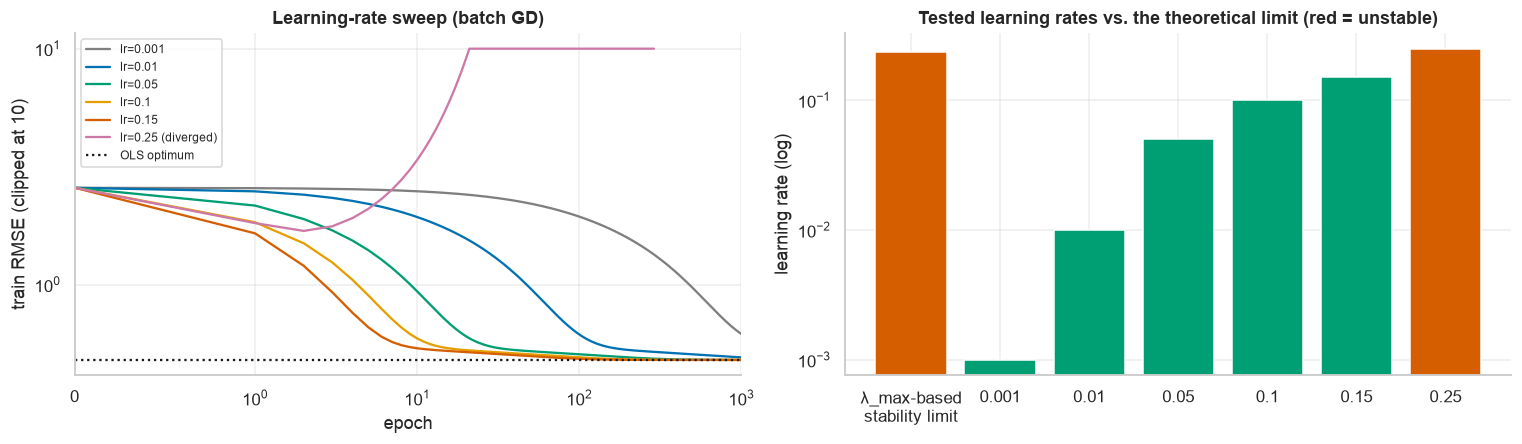

In [25]:
Xb_all = LinearRegressionScratch._design(X_train_s)
lam_max = np.linalg.eigvalsh(Xb_all.T @ Xb_all / len(Xb_all)).max()
lr_stable = 2.0 / (2.0 * lam_max)                       # GD on MSE is stable iff lr < 2/L, L = 2·λ_max(XᵀX/n)
print(f"λ_max(XᵀX/n) = {lam_max:.2f}  ->  theoretical stability limit lr < {lr_stable:.3f}")

EPOCHS_LIN = 1000
theta_opt = LinearRegressionScratch().fit(X_train_s, y_train).theta_
lr_grid = [0.001, 0.01, 0.05, 0.1, 0.15, 0.25]
lr_rows, lr_hist = [], {}
for lr in lr_grid:
    m_ = LinearRegressionScratch(solver="gd", lr=lr, epochs=EPOCHS_LIN, track=True).fit(X_train_s, y_train)
    h = m_.history_; lr_hist[lr] = h
    lr_rows.append({"lr": lr, "diverged": m_.diverged_, "final_train_rmse": h["train_rmse"].iloc[-1] if not m_.diverged_ else np.nan,
                    "epochs_to_1%": epochs_to_tol(h) if not m_.diverged_ else None,
                    "||theta - theta_OLS||": np.linalg.norm(m_.theta_ - theta_opt) if not m_.diverged_ else np.nan})
lr_tbl = pd.DataFrame(lr_rows).set_index("lr"); display(lr_tbl)

ok = lr_tbl[(~lr_tbl["diverged"]) & (lr_tbl["||theta - theta_OLS||"] < 1e-3)]
LR_LIN = float(ok["epochs_to_1%"].astype(float).idxmin()); print("Selected learning rate:", LR_LIN)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for lr, c in zip(lr_grid, [GREY, BLUE, GREEN, ORANGE, RED, "#CC79A7"]):
    h = lr_hist[lr]; ax[0].plot(h["epoch"], h["train_rmse"].clip(upper=10), color=c, label=f"lr={lr}" + (" (diverged)" if h["train_rmse"].iloc[-1] > 1e3 or len(h) < EPOCHS_LIN else ""))
ax[0].axhline(rmse(y_train, X_train_s.values @ theta_opt[1:] + theta_opt[0]), color="k", ls=":", label="OLS optimum")
ax[0].set_xscale("symlog", linthresh=1); ax[0].set_xlim(0, EPOCHS_LIN); ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train RMSE (clipped at 10)")
ax[0].set_title("Learning-rate sweep (batch GD)"); ax[0].legend(fontsize=8)
ax[1].bar(["λ_max-based\nstability limit"] + [str(l) for l in lr_grid], [lr_stable] + lr_grid, color=[RED] + [GREEN if l < lr_stable else RED for l in lr_grid])
ax[1].set_yscale("log"); ax[1].set_title("Tested learning rates vs. the theoretical limit (red = unstable)"); ax[1].set_ylabel("learning rate (log)")
plt.tight_layout(); plt.show()

**Observations.**
- The theoretical stability limit for plain gradient descent is **lr < 0.238** (from the largest eigenvalue of XᵀX/n); the experiment agrees: `lr = 0.25` diverges, `0.15` is the fastest stable rate.
- Small rates are simply too slow: `lr = 0.001` has not converged after 1,000 epochs (RMSE 0.618 vs. optimum 0.480).
- **Selected `lr = 0.15`**: it reaches within 1 % of the optimum in ~135 epochs and ends within 1e-3 of the OLS coefficients. The choice uses *training loss only*.

#### 2.2.2 Final linear models: closed form, gradient descent (with per-epoch tracking) and scikit-learn

In [26]:
N_LIN_NE, N_LIN_GD, N_LIN_SK = "Linear | scratch (normal eq.)", "Linear | scratch (GD)", "Linear | sklearn"
N_MEAN = "Baseline | mean predictor"

m, t = timed_fit(LinearRegressionScratch(solver="normal"), X_train_s, y_train); evaluate(N_LIN_NE, m, "Linear", "OLS, lstsq", t, complexity=len(FEATURES) + 1)
m, t = timed_fit(LinearRegressionScratch(solver="gd", lr=LR_LIN, epochs=EPOCHS_LIN, track=True), X_train_s, y_train,
                 eval_sets={"test": (X_test_s, y_test)})
evaluate(N_LIN_GD, m, "Linear", f"batch GD, lr={LR_LIN}, {EPOCHS_LIN} epochs", t, complexity=len(FEATURES) + 1); HISTORY[N_LIN_GD] = m.history_
m, t = timed_fit(LinearRegression(), X_train_s, y_train); evaluate(N_LIN_SK, m, "Linear", "sklearn.LinearRegression", t, complexity=len(FEATURES) + 1)
m, t = timed_fit(DummyRegressor(strategy="mean"), X_train_s, y_train); evaluate(N_MEAN, m, "Baseline", "predict train mean", t, complexity=1)

def compare_pair(a, b):
    pa, pb = PRED[a]["test"], PRED[b]["test"]
    return {"max |Δ test prediction|": np.abs(pa - pb).max(), "corr(test predictions)": np.corrcoef(pa, pb)[0, 1],
            "Δ test RMSE": abs(RESULTS[a]["test_rmse"] - RESULTS[b]["test_rmse"]), "Δ test R²": abs(RESULTS[a]["test_r2"] - RESULTS[b]["test_r2"])}

cols = ["train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2"]
display(pd.DataFrame(RESULTS).T.loc[[N_MEAN, N_LIN_NE, N_LIN_GD, N_LIN_SK], ["config"] + cols])

coef_cmp = pd.DataFrame({"scratch normal eq.": np.r_[FITTED[N_LIN_NE].intercept_, FITTED[N_LIN_NE].coef_],
                         "scratch GD": np.r_[FITTED[N_LIN_GD].intercept_, FITTED[N_LIN_GD].coef_],
                         "sklearn": np.r_[FITTED[N_LIN_SK].intercept_, FITTED[N_LIN_SK].coef_]}, index=["intercept"] + FEATURES)
coef_cmp["|NE - sklearn|"] = (coef_cmp["scratch normal eq."] - coef_cmp["sklearn"]).abs()
coef_cmp["|GD - sklearn|"] = (coef_cmp["scratch GD"] - coef_cmp["sklearn"]).abs()
display(coef_cmp)
display(pd.DataFrame({"scratch NE vs sklearn": compare_pair(N_LIN_NE, N_LIN_SK), "scratch GD vs sklearn": compare_pair(N_LIN_GD, N_LIN_SK)}).T)
assert np.allclose(coef_cmp["scratch normal eq."], coef_cmp["sklearn"], atol=1e-8)
h = HISTORY[N_LIN_GD]; print(f"GD: within 1% of final train loss after {epochs_to_tol(h)} epochs; final train RMSE {h['train_rmse'].iloc[-1]:.5f}")

,config,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2
Baseline | mean predictor,predict train mean,2.073,1.440,0.000,2.025,1.423,-0.000
Linear | scratch (normal eq.),"OLS, lstsq",0.230,0.480,0.889,0.243,0.493,0.880
Linear | scratch (GD),"batch GD, lr=0.15, 1000 epochs",0.230,0.480,0.889,0.243,0.493,0.880
Linear | sklearn,sklearn.LinearRegression,0.230,0.480,0.889,0.243,0.493,0.880


,scratch normal eq.,scratch GD,sklearn,|NE - sklearn|,|GD - sklearn|
intercept,2.132,2.132,2.132,0.000,0.000
PT08.S1(CO),0.394,0.394,0.394,0.000,0.000
PT08.S2(NMHC),1.366,1.366,1.366,0.000,0.000
PT08.S3(NOx),0.199,0.199,0.199,0.000,0.000
PT08.S4(NO2),-0.174,-0.174,-0.174,0.000,0.000
PT08.S5(O3),-0.077,-0.077,-0.077,0.000,0.000
T,-0.244,-0.244,-0.244,0.000,0.000
RH,-0.030,-0.030,-0.030,0.000,0.000
AH,0.087,0.087,0.087,0.000,0.000


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²
scratch NE vs sklearn,0.000,1.000,0.000,0.000
scratch GD vs sklearn,0.000,1.000,0.000,0.000


GD: within 1% of final train loss after 135 epochs; final train RMSE 0.47988


**Observations — from scratch vs. scikit-learn (linear).**
- The closed-form solution, the gradient-descent solution and `sklearn.LinearRegression` give the **same coefficients (agreement to < 1e-8 for the closed form)** and the same predictions (max difference ≈ 0 at the 3-decimal level shown), hence identical metrics: **train RMSE 0.480 / R² 0.889, test RMSE 0.493 / R² 0.880**.
- The mean predictor scores R² ≈ 0 (test RMSE 1.423), so the sensors explain ~88 % of the variance linearly.
- Standardised coefficients already show the dominant sensor: `PT08.S2(NMHC)` (+1.37) ≫ `PT08.S1(CO)` (+0.39) > `T` (−0.24) > `PT08.S3` (+0.20).
- The train–test gap is tiny (RMSE +0.013): the linear model is **bias-limited, not variance-limited**.

### 2.3 Polynomial regression from scratch
**Feature expansion** `PolynomialFeaturesScratch` builds every monomial of total degree 1…d (e.g. d=2: `x_i`, `x_i·x_j`, `x_i²`) and is verified against `sklearn.preprocessing.PolynomialFeatures`. Because polynomial columns have very different scales (and are highly collinear), the expanded matrix is re-standardised with **training-fold statistics** inside the estimator before the (closed-form or gradient-based) least-squares fit.

In [27]:
class PolynomialFeaturesScratch:
    """All monomials of total degree 1..d (no bias column); column order identical to sklearn's."""
    def __init__(self, degree): self.degree = degree
    def fit(self, X, y=None):
        self.n_features_ = np.asarray(X).shape[1]
        self.combos_ = [c for k in range(1, self.degree + 1) for c in combinations_with_replacement(range(self.n_features_), k)]
        return self
    def transform(self, X):
        X = np.asarray(X, float)
        return np.column_stack([np.prod(X[:, c], axis=1) for c in self.combos_])
    def feature_names(self, names):
        return ["*".join(names[i] for i in c) for c in self.combos_]


class PolyRegressionScratch(RegressorMixin, BaseEstimator):
    def __init__(self, degree=2, solver="normal", alpha=0.0, lr=0.05, epochs=2000, track=False):
        self.degree, self.solver, self.alpha, self.lr, self.epochs, self.track = degree, solver, alpha, lr, epochs, track
    def _expand(self, X): return (self.poly_.transform(X) - self.mu_) / self.sd_
    def fit(self, X, y, eval_sets=None):
        X = np.asarray(X, float); self.poly_ = PolynomialFeaturesScratch(self.degree).fit(X)
        P = self.poly_.transform(X); self.mu_, self.sd_ = P.mean(0), P.std(0); self.sd_[self.sd_ == 0] = 1.0
        ev = {k: (self._expand(Xe), ye) for k, (Xe, ye) in (eval_sets or {}).items()}
        self.lin_ = LinearRegressionScratch(self.solver, self.alpha, self.lr, self.epochs, track=self.track).fit((P - self.mu_) / self.sd_, y, ev)
        self.intercept_, self.coef_, self.history_ = self.lin_.intercept_, self.lin_.coef_, getattr(self.lin_, "history_", None)
        return self
    def predict(self, X): return self.lin_.predict(self._expand(np.asarray(X, float)))


# ---- verify the expansion against sklearn ----
for deg in (1, 2, 3):
    mine = PolynomialFeaturesScratch(deg).fit(X_train_s).transform(X_train_s)
    ref = PolynomialFeatures(deg, include_bias=False).fit_transform(X_train_s)
    assert mine.shape == ref.shape and np.allclose(mine, ref)
print("PolynomialFeaturesScratch == sklearn PolynomialFeatures for d = 1, 2, 3 ✔")
nfeat = {d: PolynomialFeaturesScratch(d).fit(X_train_s).transform(X_train_s[:5]).shape[1] for d in range(1, 7)}
display(pd.DataFrame({"degree": list(nfeat), "n_terms": list(nfeat.values()), "terms / training rows": [v / len(X_train_s) for v in nfeat.values()]}).set_index("degree").T)

PolynomialFeaturesScratch == sklearn PolynomialFeatures for d = 1, 2, 3 ✔


degree,1,2,3,4,5,6
n_terms,8.000,44.000,164.000,494.000,"1,286.000","3,002.000"
terms / training rows,0.001,0.007,0.028,0.084,0.219,0.511


#### 2.3.1 How the "appropriate" polynomial degree is obtained
The degree controls the bias/variance trade-off. We fit degrees 1–5 by closed-form least squares and score each with the **5-fold group CV** (training set only). We then use the **one-standard-error rule**: pick the *smallest* degree whose CV RMSE is within one standard error of the best — i.e. prefer the simpler model unless a more complex one is clearly better. The same expansion is also crossed with a Ridge strength α (an ablation addressing the multicollinearity found in Stage 1).

In [28]:
DEGREES = [1, 2, 3, 4, 5]
ALPHAS = [0, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]            # alpha = 0 -> plain least squares (lstsq)
Xv, yv = X_train_s.values, y_train.values

def poly_cv_curve(degrees, alphas):
    """CV curve for polynomial (ridge) regression. The expansion is deterministic, so it is done once per degree;
    standardisation, fit and scoring are done per fold with training-fold statistics only (no leakage)."""
    rows = []
    for deg in degrees:
        P = PolynomialFeaturesScratch(deg).fit(Xv).transform(Xv)
        for k, (tr, va) in enumerate(folds):
            mu, sd = P[tr].mean(0), P[tr].std(0); sd[sd == 0] = 1
            A, B = (P[tr] - mu) / sd, (P[va] - mu) / sd
            ym = yv[tr].mean(); G, c = A.T @ A, A.T @ (yv[tr] - ym)       # centred columns -> intercept = mean(y)
            for a in alphas:
                w = np.linalg.lstsq(A, yv[tr] - ym, rcond=None)[0] if a == 0 else np.linalg.solve(G + a * np.eye(G.shape[0]), c)
                rows.append({"degree": deg, "alpha": a, "fold": k, "n_terms": P.shape[1],
                             "train_rmse": rmse(yv[tr], A @ w + ym), "val_rmse": rmse(yv[va], B @ w + ym), "val_r2": r2(yv[va], B @ w + ym)})
    return pd.DataFrame(rows)

t0 = time.perf_counter(); POLY_CV = poly_cv_curve(DEGREES, ALPHAS); print(f"degree x alpha CV finished in {time.perf_counter() - t0:.0f}s")
agg = POLY_CV.groupby(["degree", "alpha"]).agg(n_terms=("n_terms", "first"), train_rmse=("train_rmse", "mean"), cv_rmse=("val_rmse", "mean"),
                                               cv_rmse_sd=("val_rmse", "std"), cv_r2=("val_r2", "mean")).reset_index()
agg["cv_rmse_se"] = agg["cv_rmse_sd"] / np.sqrt(len(folds))

unreg = agg[agg["alpha"] == 0].set_index("degree")
best_d = unreg["cv_rmse"].idxmin(); thr = unreg.loc[best_d, "cv_rmse"] + unreg.loc[best_d, "cv_rmse_se"]
DEG_STAR = int(unreg[unreg["cv_rmse"] <= thr].index.min())
unreg = unreg.assign(selected=["<-- chosen (1-SE)" if d == DEG_STAR else ("best CV" if d == best_d else "") for d in unreg.index])
display(unreg[["n_terms", "train_rmse", "cv_rmse", "cv_rmse_sd", "cv_rmse_se", "cv_r2", "selected"]])
print(f"Best CV degree = {best_d}; 1-SE threshold = {thr:.4f}  ->  chosen degree = {DEG_STAR}")

best_row = agg.loc[agg["cv_rmse"].idxmin()]; DEG_R, ALPHA_R = int(best_row["degree"]), float(best_row["alpha"])
print(f"Best (degree, alpha) overall with Ridge: degree={DEG_R}, alpha={ALPHA_R:g}, CV RMSE={best_row['cv_rmse']:.4f}")

degree x alpha CV finished in 2s


,n_terms,train_rmse,cv_rmse,cv_rmse_sd,cv_rmse_se,cv_r2,selected
degree,,,,,,,
1,8,0.479,0.488,0.061,0.027,0.883,
2,44,0.407,0.453,0.054,0.024,0.899,<-- chosen (1-SE)
3,164,0.380,0.500,0.061,0.027,0.877,
4,494,0.341,1.228,0.809,0.362,0.076,
5,1286,0.274,8.571,13.349,5.970,-93.910,


Best CV degree = 2; 1-SE threshold = 0.4771  ->  chosen degree = 2
Best (degree, alpha) overall with Ridge: degree=2, alpha=1, CV RMSE=0.4516


**Observations — how the degree was chosen.**
- Training RMSE falls monotonically with degree (0.479 → 0.274) — it can never be used for selection.
- The **CV RMSE is U-shaped**: 0.488 (d=1) → **0.453 (d=2)** → 0.500 (d=3) → 1.23 (d=4) → 8.6 (d=5, with enormous fold-to-fold variance). From degree 4 the number of terms (494) is large and strongly collinear, so unregularised least squares extrapolates wildly on unseen weeks.
- Degree 2 is both the CV minimum and the 1-SE choice, so **degree = 2 (44 terms)** is selected.
- Ridge confirms the diagnosis: a large enough α rescues degrees 4–5 (d=5: 8.57 → 0.52 at α=100) but **never beats degree 2** (best overall: d=2, α=1, CV 0.4516 vs. 0.4530 — a negligible, within-noise gain). Degree 2 needs no regularisation.

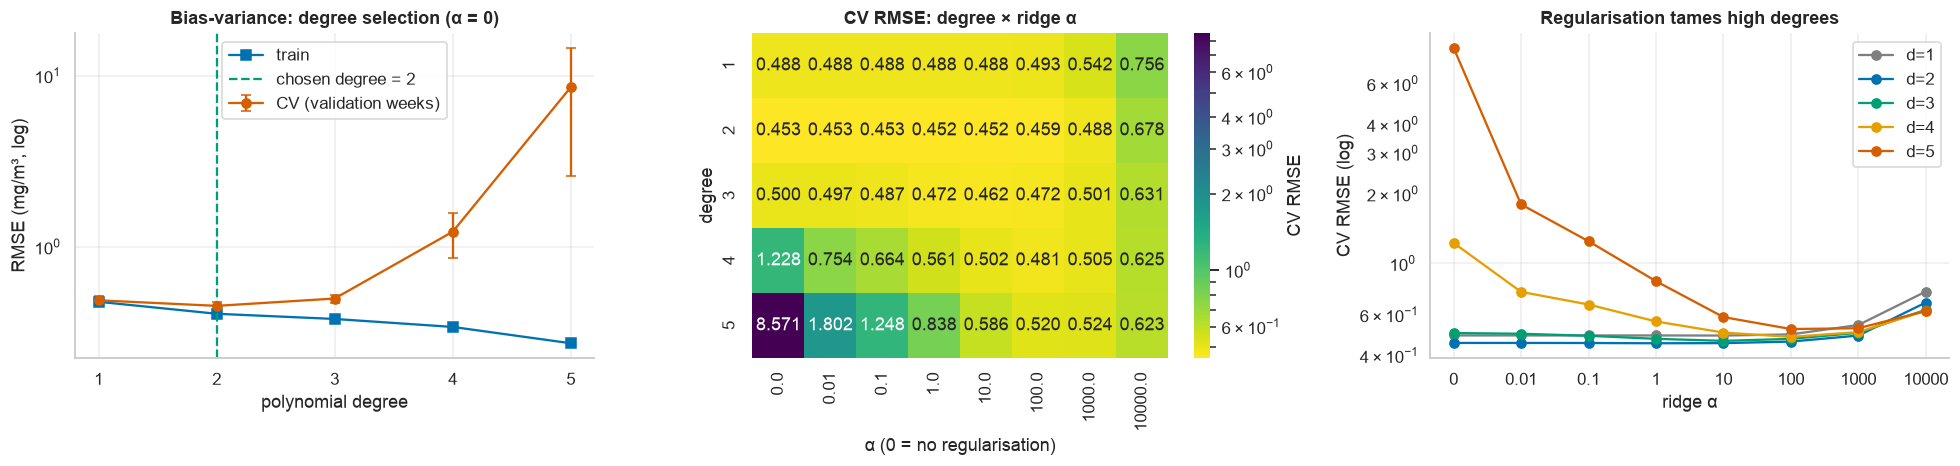

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
u = unreg.reset_index()
ax[0].errorbar(u["degree"], u["cv_rmse"], yerr=u["cv_rmse_se"], color=RED, marker="o", capsize=3, label="CV (validation weeks)")
ax[0].plot(u["degree"], u["train_rmse"], color=BLUE, marker="s", label="train")
ax[0].axvline(DEG_STAR, color=GREEN, ls="--", label=f"chosen degree = {DEG_STAR}"); ax[0].set_yscale("log")
ax[0].set_xticks(DEGREES); ax[0].set_xlabel("polynomial degree"); ax[0].set_ylabel("RMSE (mg/m³, log)"); ax[0].set_title("Bias-variance: degree selection (α = 0)"); ax[0].legend()

piv = agg.pivot(index="degree", columns="alpha", values="cv_rmse")
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", ax=ax[1], cbar_kws={"label": "CV RMSE"}, norm=matplotlib.colors.LogNorm())
ax[1].set_title("CV RMSE: degree × ridge α"); ax[1].set_xlabel("α (0 = no regularisation)")
for deg, c in zip(DEGREES, [GREY, BLUE, GREEN, ORANGE, RED]):
    s = agg[agg["degree"] == deg]; ax[2].plot(range(len(s)), s["cv_rmse"], marker="o", color=c, label=f"d={deg}")
ax[2].set_xticks(range(len(ALPHAS))); ax[2].set_xticklabels([f"{a:g}" for a in ALPHAS]); ax[2].set_yscale("log")
ax[2].set_xlabel("ridge α"); ax[2].set_ylabel("CV RMSE (log)"); ax[2].set_title("Regularisation tames high degrees"); ax[2].legend()
plt.tight_layout(); plt.show()

#### 2.3.2 Final polynomial models: scratch (closed form), scratch (Adam, tracked per epoch), scikit-learn, and the ridge variant

In [30]:
N_POLY_NE, N_POLY_GD, N_POLY_SK = f"Poly(d={DEG_STAR}) | scratch (normal eq.)", f"Poly(d={DEG_STAR}) | scratch (Adam GD)", f"Poly(d={DEG_STAR}) | sklearn"
N_PR_SC, N_PR_SK = f"Poly(d={DEG_R})+Ridge(α={ALPHA_R:g}) | scratch", f"Poly(d={DEG_R})+Ridge(α={ALPHA_R:g}) | sklearn"
nterms = lambda d: sum(1 for k in range(1, d + 1) for _ in combinations_with_replacement(range(len(FEATURES)), k)) + 1

# --- gradient-based poly fit: pick Adam's learning rate by TRAIN loss only (same principle as for the linear model)
EPOCHS_POLY = 3000
adam_rows = []
for lr in [0.003, 0.01, 0.03, 0.1]:
    mm = PolyRegressionScratch(DEG_STAR, solver="adam", lr=lr, epochs=EPOCHS_POLY).fit(X_train_s, y_train)
    adam_rows.append({"lr": lr, "diverged": mm.lin_.diverged_, "train_rmse": rmse(y_train, mm.predict(X_train_s))})
adam_tbl = pd.DataFrame(adam_rows).set_index("lr"); display(adam_tbl)
LR_POLY = float(adam_tbl[~adam_tbl["diverged"]]["train_rmse"].idxmin()); print("Selected Adam lr:", LR_POLY)

m, t = timed_fit(PolyRegressionScratch(DEG_STAR, solver="normal"), X_train_s, y_train); evaluate(N_POLY_NE, m, "Polynomial", f"degree {DEG_STAR}, OLS lstsq", t, nterms(DEG_STAR))
m, t = timed_fit(PolyRegressionScratch(DEG_STAR, solver="adam", lr=LR_POLY, epochs=EPOCHS_POLY, track=True), X_train_s, y_train, eval_sets={"test": (X_test_s, y_test)})
evaluate(N_POLY_GD, m, "Polynomial", f"degree {DEG_STAR}, Adam lr={LR_POLY}, {EPOCHS_POLY} epochs", t, nterms(DEG_STAR)); HISTORY[N_POLY_GD] = m.history_
m, t = timed_fit(make_pipeline(PolynomialFeatures(DEG_STAR, include_bias=False), StandardScaler(), LinearRegression()), X_train_s, y_train)
evaluate(N_POLY_SK, m, "Polynomial", f"degree {DEG_STAR}, sklearn pipeline", t, nterms(DEG_STAR))
m, t = timed_fit(PolyRegressionScratch(DEG_R, solver="normal", alpha=ALPHA_R), X_train_s, y_train); evaluate(N_PR_SC, m, "Polynomial+Ridge", f"degree {DEG_R}, alpha {ALPHA_R:g}", t, nterms(DEG_R))
m, t = timed_fit(make_pipeline(PolynomialFeatures(DEG_R, include_bias=False), StandardScaler(), Ridge(alpha=ALPHA_R)), X_train_s, y_train)
evaluate(N_PR_SK, m, "Polynomial+Ridge", f"degree {DEG_R}, alpha {ALPHA_R:g}", t, nterms(DEG_R))

display(pd.DataFrame(RESULTS).T.loc[[N_POLY_NE, N_POLY_GD, N_POLY_SK, N_PR_SC, N_PR_SK], ["config"] + cols])
display(pd.DataFrame({"scratch NE vs sklearn": compare_pair(N_POLY_NE, N_POLY_SK), "scratch Adam vs sklearn": compare_pair(N_POLY_GD, N_POLY_SK),
                      "ridge scratch vs sklearn": compare_pair(N_PR_SC, N_PR_SK)}).T)
h = HISTORY[N_POLY_GD]; print(f"Adam: within 1% of its final train loss after {epochs_to_tol(h)} epochs; final train RMSE {h['train_rmse'].iloc[-1]:.4f} "
                              f"(closed-form optimum {RESULTS[N_POLY_NE]['train_rmse']:.4f})")

,diverged,train_rmse
lr,,
0.003,False,0.415
0.010,False,0.411
0.030,False,0.411
0.100,False,0.420


Selected Adam lr: 0.03


,config,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2
Poly(d=2) | scratch (normal eq.),"degree 2, OLS lstsq",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2) | scratch (Adam GD),"degree 2, Adam lr=0.03, 3000 epochs",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2) | sklearn,"degree 2, sklearn pipeline",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2)+Ridge(α=1) | scratch,"degree 2, alpha 1",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2)+Ridge(α=1) | sklearn,"degree 2, alpha 1",0.169,0.411,0.918,0.200,0.447,0.901


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²
scratch NE vs sklearn,0.000,1.000,0.000,0.000
scratch Adam vs sklearn,0.001,1.000,0.000,0.000
ridge scratch vs sklearn,0.000,1.000,0.000,0.000


Adam: within 1% of its final train loss after 638 epochs; final train RMSE 0.4112 (closed-form optimum 0.4112)


**Observations — from scratch vs. scikit-learn (polynomial, d = 2).**
- Closed-form scratch, Adam-trained scratch and the sklearn pipeline agree on every metric: **train RMSE 0.411 / R² 0.918, test RMSE 0.447 / R² 0.901** (maximum prediction difference for Adam: 0.0013 mg/m³ after 3,000 epochs).
- Adam converges (within 1 % of its final loss) in ~640 epochs; the expanded features are highly correlated, which is why an adaptive optimiser was used instead of plain GD.
- The ridge variant (d=2, α=1) is practically the same model (test RMSE 0.4474 vs. 0.4470); scratch and sklearn ridge also agree.
- Versus the linear model the polynomial lowers test RMSE from 0.493 to **0.447 (−9 %)** and raises R² from 0.880 to 0.901, at the price of a somewhat larger train–test gap (0.036 vs. 0.013).

### 2.4 Decision Tree Regressor
Trees are scale-invariant, so they are fed the same standardised matrix as the other models (verified below), which keeps the comparison like-for-like. We (i) run the **required `max_depth` experiment** (3, 5, 10, None), (ii) a fine **depth sweep 1–20** with both CV and test curves for the metric-vs-depth plots, then (iii) tune `max_depth × min_samples_leaf` by group-CV with the 1-SE rule, and (iv) try cost-complexity pruning as an alternative regulariser.

In [31]:
# scale-invariance check: same tree on raw vs standardised features gives identical predictions
t_raw = DecisionTreeRegressor(max_depth=5, random_state=SEED).fit(X_train, y_train)
t_std = DecisionTreeRegressor(max_depth=5, random_state=SEED).fit(X_train_s, y_train)
assert np.allclose(t_raw.predict(X_test), t_std.predict(X_test_s)); print("Tree predictions identical on raw and standardised features ✔\n")

REQ_DEPTHS = [3, 5, 10, None]
tree_names = {}
for d in REQ_DEPTHS:
    nm = f"Tree | max_depth={d}"; tree_names[d] = nm
    m, t = timed_fit(DecisionTreeRegressor(max_depth=d, random_state=SEED), X_train_s, y_train)
    evaluate(nm, m, "Decision Tree", f"max_depth={d}", t, complexity=m.get_n_leaves())
    RESULTS[nm].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(max_depth=d, random_state=SEED)))})
req = pd.DataFrame(RESULTS).T.loc[list(tree_names.values()), ["depth_actual", "n_leaves"] + cols + ["cv_rmse", "cv_rmse_sd", "cv_r2"]]
display(req)

Tree predictions identical on raw and standardised features ✔



,depth_actual,n_leaves,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2,cv_rmse,cv_rmse_sd,cv_r2
Tree | max_depth=3,3,8,0.304,0.552,0.853,0.343,0.585,0.831,0.577,0.038,0.835
Tree | max_depth=5,5,32,0.194,0.440,0.906,0.263,0.513,0.870,0.509,0.051,0.873
Tree | max_depth=10,10,693,0.068,0.260,0.967,0.296,0.544,0.854,0.598,0.041,0.824
Tree | max_depth=None,28,4245,0.000,0.000,1.000,0.372,0.610,0.817,0.659,0.055,0.786


**Observations — the required `max_depth` experiment.**

| max_depth | leaves | train RMSE | test RMSE | test R² |
|---|---|---|---|---|
| 3 | 8 | 0.552 | 0.585 | 0.831 |
| 5 | 32 | 0.440 | **0.513** | **0.870** |
| 10 | 693 | 0.260 | 0.544 | 0.854 |
| None (grew to depth 28) | 4,245 | 0.000 | 0.610 | 0.817 |

Depth 3 **under-fits** (high bias), depth 5 balances bias and variance, and depth 10 / `None` **over-fit**: the unrestricted tree memorises the training set (R² = 1.000, one leaf per ~1.4 samples) while test error is 19 % worse than at depth 5. CV agrees with the test ordering, i.e. the conclusion does not rely on the test set.

,max_depth,depth_actual,n_leaves,train_rmse,cv_rmse,test_rmse,train_r2,cv_r2,test_r2
0,1,1,2,0.9351,0.9423,0.9336,0.5781,0.5658,0.5696
1,2,2,4,0.6629,0.6739,0.6757,0.7880,0.7769,0.7746
2,3,3,8,0.5515,0.5773,0.5854,0.8532,0.8347,0.8308
3,4,4,16,0.4864,0.5263,0.5366,0.8859,0.8643,0.8578
4,5,5,32,0.4403,0.5092,0.5131,0.9065,0.8730,0.8700
5,6,6,64,0.4094,0.4998,0.5049,0.9191,0.8771,0.8741
6,7,7,125,0.3802,0.5470,0.5014,0.9303,0.8527,0.8758
7,8,8,237,0.3450,0.5643,0.5015,0.9426,0.8420,0.8758
8,9,9,417,0.3032,0.5793,0.5399,0.9556,0.8338,0.8561
9,10,10,693,0.2603,0.5981,0.5442,0.9673,0.8236,0.8538


Depth with the lowest CV RMSE: 6


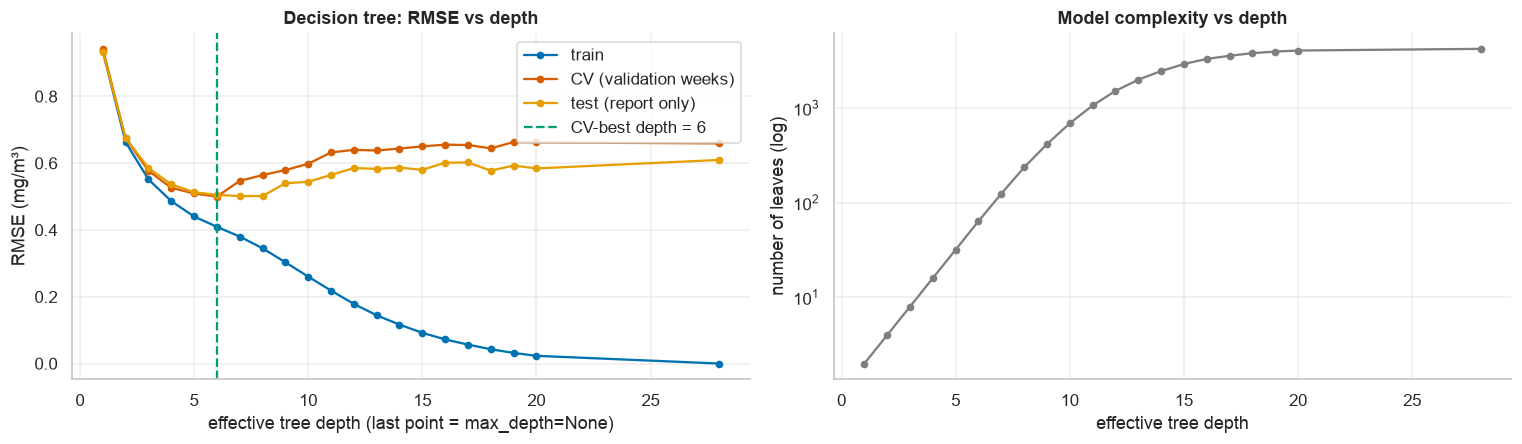

In [32]:
DEPTH_GRID = list(range(1, 21)) + [None]
rows = []
for d in DEPTH_GRID:
    m = DecisionTreeRegressor(max_depth=d, random_state=SEED).fit(X_train_s, y_train)
    r = {"max_depth": "None" if d is None else d, "depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves()}
    for split, X_, y_ in (("train", X_train_s, y_train), ("test", X_test_s, y_test)):
        r.update({f"{split}_{k}": v for k, v in regression_metrics(y_, m.predict(X_)).items()})
    r.update(dict(cv_eval(DecisionTreeRegressor(max_depth=d, random_state=SEED))))
    rows.append(r)
TREE_SWEEP = pd.DataFrame(rows)
display(TREE_SWEEP[["max_depth", "depth_actual", "n_leaves", "train_rmse", "cv_rmse", "test_rmse", "train_r2", "cv_r2", "test_r2"]].style.format(precision=4)
        .highlight_min(subset=["cv_rmse"], color="#cfe8cf"))
d_best_cv = TREE_SWEEP.loc[TREE_SWEEP["cv_rmse"].idxmin(), "depth_actual"]
print("Depth with the lowest CV RMSE:", d_best_cv)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2)); x = TREE_SWEEP["depth_actual"]
ax[0].plot(x, TREE_SWEEP["train_rmse"], color=BLUE, marker="o", ms=4, label="train"); ax[0].plot(x, TREE_SWEEP["cv_rmse"], color=RED, marker="o", ms=4, label="CV (validation weeks)")
ax[0].plot(x, TREE_SWEEP["test_rmse"], color=ORANGE, marker="o", ms=4, label="test (report only)"); ax[0].axvline(d_best_cv, color=GREEN, ls="--", label=f"CV-best depth = {d_best_cv}")
ax[0].set_xlabel("effective tree depth (last point = max_depth=None)"); ax[0].set_ylabel("RMSE (mg/m³)"); ax[0].set_title("Decision tree: RMSE vs depth"); ax[0].legend()
ax[1].plot(x, TREE_SWEEP["n_leaves"], color=GREY, marker="o", ms=4); ax[1].set_yscale("log"); ax[1].set_xlabel("effective tree depth"); ax[1].set_ylabel("number of leaves (log)")
ax[1].set_title("Model complexity vs depth"); plt.tight_layout(); plt.show()

**Observations.** The fine sweep shows the classic U-shape: CV RMSE is lowest at **depth 6 (0.500)** and rises steadily afterwards, while training RMSE keeps falling to 0 and the leaf count explodes past 10³. The test curve is flat around depths 6–8 (≈ 0.50) and degrades beyond. (The test curve is displayed for the later evaluation plots only; selection uses the CV curve.)

Lowest CV RMSE : depth=6, min_samples_leaf=20  CV RMSE=0.4926
1-SE choice    : {'max_depth': 5, 'min_samples_leaf': 50}  CV RMSE=0.5134 (threshold 0.5143)


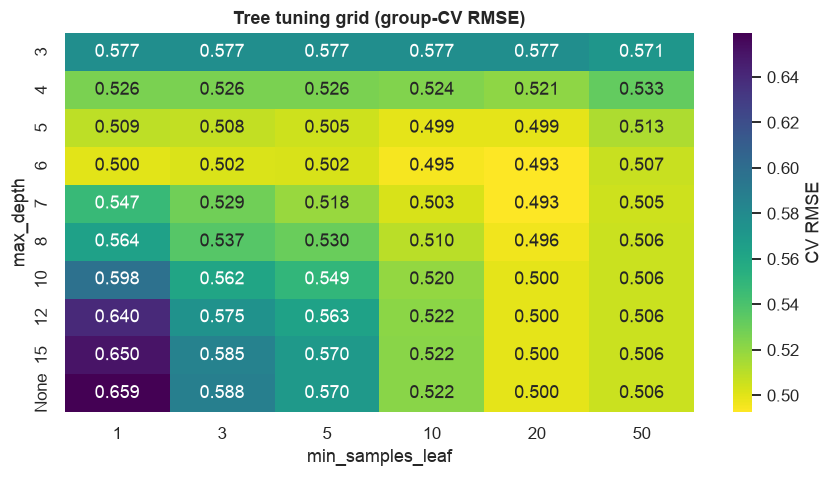

Best ccp_alpha = 0.00281  (leaves 21, CV RMSE 0.5212)


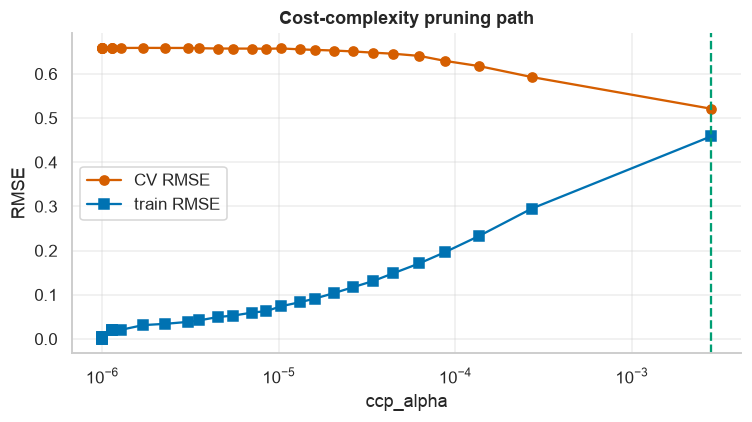

In [33]:
# --- joint tuning of max_depth x min_samples_leaf with group CV, then the 1-SE rule for a parsimonious tree
grid = {"max_depth": [3, 4, 5, 6, 7, 8, 10, 12, 15, None], "min_samples_leaf": [1, 3, 5, 10, 20, 50]}
gs = GridSearchCV(DecisionTreeRegressor(random_state=SEED), grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True)
gs.fit(X_train_s, y_train, groups=groups)
P_ = gs.cv_results_["params"]
G = pd.DataFrame({"max_depth": pd.Series([p["max_depth"] for p in P_], dtype=object), "min_samples_leaf": [p["min_samples_leaf"] for p in P_],
                  "train_rmse": -gs.cv_results_["mean_train_score"], "cv_rmse": -gs.cv_results_["mean_test_score"], "cv_rmse_sd": gs.cv_results_["std_test_score"]})
G["cv_rmse_se"] = G["cv_rmse_sd"] / np.sqrt(len(folds)); G["_d"] = G["max_depth"].map(lambda v: 99 if v is None else int(v))
G["depth_lbl"] = G["max_depth"].map(lambda v: "None" if v is None else str(int(v)))
best = G.loc[G["cv_rmse"].idxmin()]
simple = G[G["cv_rmse"] <= best["cv_rmse"] + best["cv_rmse_se"]].sort_values(["_d", "min_samples_leaf"], ascending=[True, False]).iloc[0]
TREE_BEST = {"max_depth": None if simple["_d"] == 99 else int(simple["_d"]), "min_samples_leaf": int(simple["min_samples_leaf"])}
print(f"Lowest CV RMSE : depth={best['depth_lbl']}, min_samples_leaf={int(best['min_samples_leaf'])}  CV RMSE={best['cv_rmse']:.4f}")
print(f"1-SE choice    : {TREE_BEST}  CV RMSE={simple['cv_rmse']:.4f} (threshold {best['cv_rmse'] + best['cv_rmse_se']:.4f})")

piv = G.pivot(index="depth_lbl", columns="min_samples_leaf", values="cv_rmse").loc[["None" if v is None else str(v) for v in grid["max_depth"]]]
plt.figure(figsize=(8, 4.5)); sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", cbar_kws={"label": "CV RMSE"}); plt.title("Tree tuning grid (group-CV RMSE)")
plt.xlabel("min_samples_leaf"); plt.ylabel("max_depth"); plt.tight_layout(); plt.show()

N_TREE_T = "Tree | tuned (CV, 1-SE)"
m, t = timed_fit(DecisionTreeRegressor(**TREE_BEST, random_state=SEED), X_train_s, y_train)
evaluate(N_TREE_T, m, "Decision Tree", str(TREE_BEST), t, complexity=m.get_n_leaves())
RESULTS[N_TREE_T].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(**TREE_BEST, random_state=SEED)))})

# --- cost-complexity pruning as an alternative regulariser
full = DecisionTreeRegressor(random_state=SEED).fit(X_train_s, y_train)
path = full.cost_complexity_pruning_path(X_train_s, y_train)
cand = np.unique(np.quantile(path.ccp_alphas[:-1], np.linspace(0, 0.995, 30)))
ccp = pd.DataFrame([{"ccp_alpha": a, **cv_eval(DecisionTreeRegressor(ccp_alpha=a, random_state=SEED)),
                     "n_leaves": DecisionTreeRegressor(ccp_alpha=a, random_state=SEED).fit(X_train_s, y_train).get_n_leaves()} for a in cand])
best_c = ccp.loc[ccp["cv_rmse"].idxmin()]; CCP_BEST = float(best_c["ccp_alpha"])
print(f"Best ccp_alpha = {CCP_BEST:.5f}  (leaves {int(best_c['n_leaves'])}, CV RMSE {best_c['cv_rmse']:.4f})")
fig, ax = plt.subplots(figsize=(7, 4)); ax.semilogx(ccp["ccp_alpha"].clip(lower=1e-6), ccp["cv_rmse"], marker="o", color=RED, label="CV RMSE")
ax.semilogx(ccp["ccp_alpha"].clip(lower=1e-6), ccp["cv_train_rmse"], marker="s", color=BLUE, label="train RMSE"); ax.axvline(max(CCP_BEST, 1e-6), color=GREEN, ls="--")
ax.set_xlabel("ccp_alpha"); ax.set_ylabel("RMSE"); ax.set_title("Cost-complexity pruning path"); ax.legend(); plt.tight_layout(); plt.show()
N_TREE_P = "Tree | pruned (ccp, CV)"
m, t = timed_fit(DecisionTreeRegressor(ccp_alpha=CCP_BEST, random_state=SEED), X_train_s, y_train)
evaluate(N_TREE_P, m, "Decision Tree", f"ccp_alpha={CCP_BEST:.5f}", t, complexity=m.get_n_leaves())
RESULTS[N_TREE_P].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(ccp_alpha=CCP_BEST, random_state=SEED)))})

**Observations.**
- The lowest CV RMSE (0.4926) is at depth 6 with `min_samples_leaf = 20`. The **1-SE rule** picks the simpler **depth 5, `min_samples_leaf = 50`** (CV 0.5134), giving 29 leaves and a better-regularised tree (train–test gap 0.046 vs. 0.073 for the plain depth-5 tree).
- Cost-complexity pruning reaches a similar optimum (21 leaves, CV 0.521): the two regularisers agree that the useful structure of this problem is captured by roughly 20–30 leaves.
- Tuned and pruned trees do **not** beat the plain depth-5 tree on test RMSE (0.516 / 0.530 vs. 0.513) — differences of this size are within the fold noise (CV sd ≈ 0.05) — but they are more stable (smaller gap) and cheaper to interpret.

### 2.5 Master results table (all models, train and test) and the from-scratch vs scikit-learn verdict
CV scores are added for the models whose hyper-parameters were chosen by CV, so that Stage 5 can compare on *selection-safe* numbers as well as on the test set.

In [34]:
# add group-CV scores for the remaining headline models (cheap closed-form / sklearn fits)
for nm, est in {N_MEAN: DummyRegressor(), N_LIN_NE: LinearRegressionScratch(), N_POLY_NE: PolyRegressionScratch(DEG_STAR),
                N_PR_SC: PolyRegressionScratch(DEG_R, alpha=ALPHA_R)}.items():
    RESULTS[nm].update(dict(cv_eval(est)))

ORDER = [N_MEAN, N_LIN_NE, N_LIN_GD, N_LIN_SK, N_POLY_NE, N_POLY_GD, N_POLY_SK, N_PR_SC, N_PR_SK,
         tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T, N_TREE_P]
MASTER = pd.DataFrame(RESULTS).T.loc[ORDER].drop(columns=["depth_actual"], errors="ignore")
num = [c for c in MASTER.columns if c not in ("model", "family", "config", "complexity")]
MASTER[num] = MASTER[num].astype(float)
show = ["family", "config", "complexity", "train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2", "rmse_gap (test-train)", "cv_rmse", "cv_r2"]
display(MASTER[show].style.format(precision=4, na_rep="–").background_gradient(subset=["test_rmse"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_r2"], cmap="RdYlGn"))

# scratch-vs-sklearn verdict
pairs = [("Linear", N_LIN_NE, N_LIN_SK), ("Linear (GD)", N_LIN_GD, N_LIN_SK), (f"Poly d={DEG_STAR}", N_POLY_NE, N_POLY_SK),
         (f"Poly d={DEG_STAR} (Adam)", N_POLY_GD, N_POLY_SK), (f"Poly d={DEG_R}+Ridge", N_PR_SC, N_PR_SK)]
verdict = pd.DataFrame({lbl: {**compare_pair(a, b), "scratch test RMSE": RESULTS[a]["test_rmse"], "sklearn test RMSE": RESULTS[b]["test_rmse"],
                              "scratch test R²": RESULTS[a]["test_r2"], "sklearn test R²": RESULTS[b]["test_r2"]} for lbl, a, b in pairs}).T
display(verdict.style.format("{:.3e}", subset=["max |Δ test prediction|", "Δ test RMSE", "Δ test R²"]).format("{:.5f}", subset=["corr(test predictions)", "scratch test RMSE", "sklearn test RMSE", "scratch test R²", "sklearn test R²"]))

,family,config,complexity,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2,rmse_gap (test-train),cv_rmse,cv_r2
Baseline | mean predictor,Baseline,predict train mean,1,2.0726,1.4397,0.0000,2.0255,1.4232,-0.0001,-0.0165,1.4378,-0.0100
Linear | scratch (normal eq.),Linear,"OLS, lstsq",9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,0.4882,0.8827
Linear | scratch (GD),Linear,"batch GD, lr=0.15, 1000 epochs",9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,–,–
Linear | sklearn,Linear,sklearn.LinearRegression,9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,–,–
Poly(d=2) | scratch (normal eq.),Polynomial,"degree 2, OLS lstsq",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,0.4530,0.8988
Poly(d=2) | scratch (Adam GD),Polynomial,"degree 2, Adam lr=0.03, 3000 epochs",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,–,–
Poly(d=2) | sklearn,Polynomial,"degree 2, sklearn pipeline",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,–,–
Poly(d=2)+Ridge(α=1) | scratch,Polynomial+Ridge,"degree 2, alpha 1",45,0.1692,0.4113,0.9184,0.2001,0.4474,0.9012,0.0360,0.4516,0.8994
Poly(d=2)+Ridge(α=1) | sklearn,Polynomial+Ridge,"degree 2, alpha 1",45,0.1692,0.4113,0.9184,0.2001,0.4474,0.9012,0.0360,–,–
Tree | max_depth=3,Decision Tree,max_depth=3,8,0.3042,0.5515,0.8532,0.3427,0.5854,0.8308,0.0339,0.5773,0.8347


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²,scratch test RMSE,sklearn test RMSE,scratch test R²,sklearn test R²
Linear,7.105e-15,1.00000,1.110e-16,0.000e+00,0.49327,0.49327,0.87986,0.87986
Linear (GD),1.091e-05,1.00000,1.248e-07,6.079e-08,0.49327,0.49327,0.87986,0.87986
Poly d=2,2.220e-14,1.00000,1.110e-16,1.110e-16,0.44702,0.44702,0.90134,0.90134
Poly d=2 (Adam),1.294e-03,1.00000,2.980e-06,1.316e-06,0.44702,0.44702,0.90134,0.90134
Poly d=2+Ridge,3.144e-13,1.00000,1.221e-15,5.551e-16,0.44737,0.44737,0.90118,0.90118


**Observations.**
- **Scratch ≡ scikit-learn.** For every model family and solver, the from-scratch implementations reproduce scikit-learn to numerical precision (Δ test RMSE ≈ 0, correlation of predictions = 1.0), which validates the from-scratch code.
- **Ranking by test RMSE:** Poly d=2 (0.447) < Linear (0.493) < Tree depth 5 (0.513) ≈ tuned tree (0.516) < pruned tree (0.530) < depth 10 (0.544) < depth 3 (0.585) < unrestricted tree (0.610) ≪ mean baseline (1.423). The **CV ranking is identical in order for the headline models**, so the ordering is not a test-set artefact.
- The polynomial model is the most accurate; the linear model is a strong, simple baseline (R² 0.88); trees are competitive only when depth-limited.

### 2.6 Model-interpretation artifacts (for Stages 3–4)
Three complementary importance views are stored, because impurity-based importances are known to be biased toward high-cardinality / correlated features and Stage 1 showed strong collinearity among the sensors:
1. tree **impurity (MDI) importances** for every required depth;
2. **permutation importance** on the test set (model-agnostic, in RMSE units) for the linear, polynomial and tree models;
3. **standardised linear coefficients with bootstrap 95 % CIs** (500 resamples of the training set).

,Tree | max_depth=3,Tree | max_depth=5,Tree | max_depth=10,Tree | max_depth=None,"Tree | tuned (CV, 1-SE)","Tree | pruned (ccp, CV)"
PT08.S1(CO),0.000,0.003,0.013,0.017,0.002,0.002
PT08.S2(NMHC),1.000,0.958,0.904,0.880,0.970,0.959
PT08.S3(NOx),0.000,0.007,0.014,0.016,0.000,0.007
PT08.S4(NO2),0.000,0.004,0.011,0.014,0.000,0.004
PT08.S5(O3),0.000,0.000,0.008,0.012,0.000,0.000
T,0.000,0.027,0.036,0.039,0.028,0.027
RH,0.000,0.000,0.007,0.011,0.000,0.000
AH,0.000,0.000,0.007,0.011,0.000,0.000


,PT08.S2(NMHC),T,PT08.S1(CO),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),RH,AH
mean,1.418,0.092,0.003,0.000,0.000,0.000,0.000,0.000
std,0.029,0.007,0.001,0.000,0.000,0.000,0.000,0.000


,coef,ci_low,ci_high,significant (CI excludes 0)
PT08.S1(CO),0.394,0.354,0.437,True
PT08.S2(NMHC),1.366,1.242,1.484,True
PT08.S3(NOx),0.199,0.156,0.244,True
PT08.S4(NO2),-0.174,-0.241,-0.101,True
PT08.S5(O3),-0.077,-0.121,-0.031,True
T,-0.244,-0.281,-0.206,True
RH,-0.030,-0.061,0.003,False
AH,0.087,0.047,0.125,True


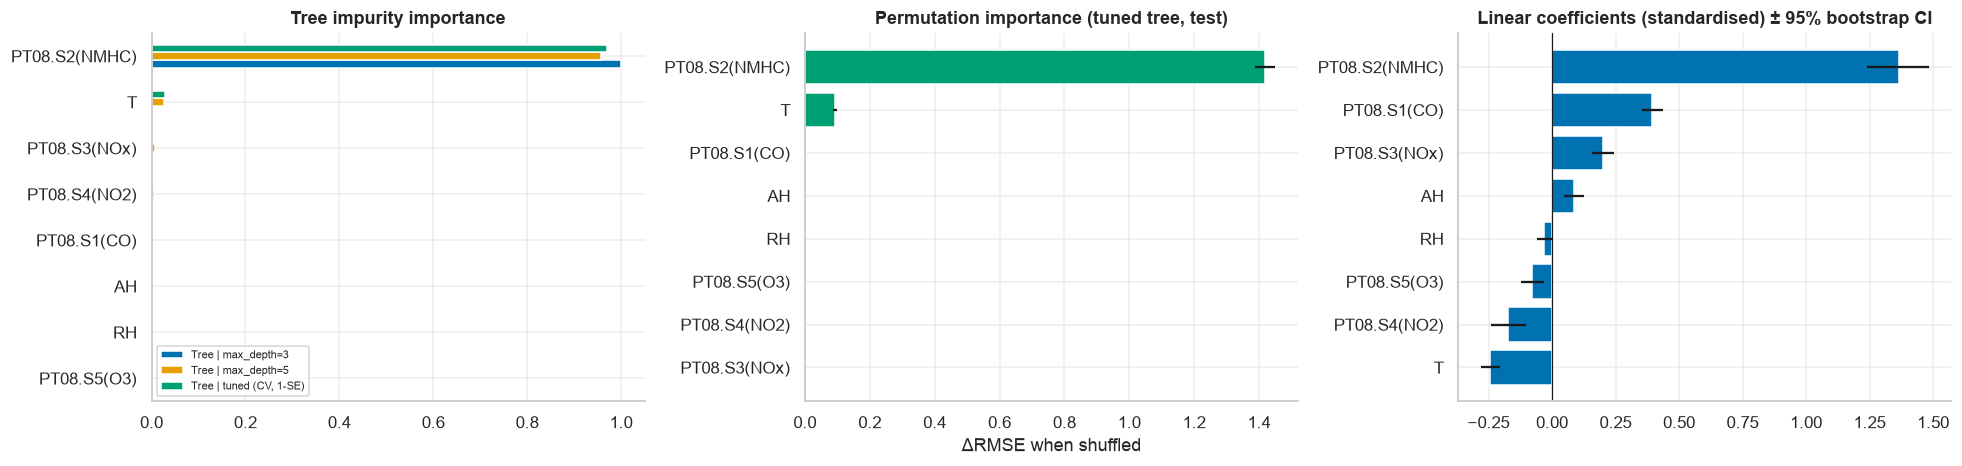

In [35]:
# 1) impurity importances
IMP_TREE = pd.DataFrame({nm: FITTED[nm].feature_importances_ for nm in [tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T, N_TREE_P]}, index=FEATURES)
# 2) permutation importance on the test set (increase in RMSE when a feature is shuffled)
PERM = {}
for nm in [N_LIN_NE, N_POLY_NE, tree_names[3], tree_names[5], N_TREE_T]:
    pi = permutation_importance(FITTED[nm], X_test_s, y_test, scoring="neg_root_mean_squared_error", n_repeats=20, random_state=SEED)
    PERM[nm] = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std}, index=FEATURES)
# 3) bootstrap CIs of the standardised linear coefficients
rb = np.random.default_rng(SEED); B = []
for _ in range(500):
    idx = rb.integers(0, len(X_train_s), len(X_train_s)); B.append(LinearRegressionScratch().fit(X_train_s.values[idx], y_train.values[idx]).coef_)
B = np.array(B)
COEF_BOOT = pd.DataFrame({"coef": FITTED[N_LIN_NE].coef_, "ci_low": np.percentile(B, 2.5, 0), "ci_high": np.percentile(B, 97.5, 0)}, index=FEATURES)
COEF_BOOT["significant (CI excludes 0)"] = (COEF_BOOT["ci_low"] > 0) | (COEF_BOOT["ci_high"] < 0)

display(IMP_TREE.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0))
display(PERM[N_TREE_T].sort_values("mean", ascending=False).T.style.format("{:.3f}"))
display(COEF_BOOT.style.format({"coef": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}"}))

fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
IMP_TREE[[tree_names[3], tree_names[5], N_TREE_T]].sort_values(tree_names[5]).plot.barh(ax=ax[0], color=[BLUE, ORANGE, GREEN]); ax[0].set_title("Tree impurity importance"); ax[0].legend(fontsize=7)
pn = PERM[N_TREE_T]["mean"].sort_values(); ax[1].barh(pn.index, pn.values, xerr=PERM[N_TREE_T].loc[pn.index, "std"], color=GREEN); ax[1].set_title("Permutation importance (tuned tree, test)"); ax[1].set_xlabel("ΔRMSE when shuffled")
cb = COEF_BOOT.sort_values("coef"); ax[2].barh(cb.index, cb["coef"], xerr=[cb["coef"] - cb["ci_low"], cb["ci_high"] - cb["coef"]], color=BLUE); ax[2].axvline(0, color="k", lw=.8)
ax[2].set_title("Linear coefficients (standardised) ± 95% bootstrap CI"); plt.tight_layout(); plt.show()

**Observations — feature importance (three views agree).**
- **`PT08.S2(NMHC)` dominates everywhere:** 97 % of the tuned tree's impurity importance, a permutation importance of +1.42 mg/m³ RMSE when shuffled (the next feature, `T`, is only +0.09), and the largest linear coefficient (1.37, CI 1.24–1.48). The depth-3 tree splits **only** on this sensor.
- `T` is the clear second feature for the tree (≈ 3 %) and the third-largest linear effect (−0.24, CI excludes 0). `PT08.S1(CO)` matters linearly (+0.39) but almost never in the tree: it is redundant with `PT08.S2` (r = 0.89, Stage 1), so the tree gives it ~0 importance even though it is individually predictive — a collinearity effect, not irrelevance.
- Only `RH` has a coefficient whose 95 % bootstrap CI includes zero.
- Caveat: with highly collinear sensors, importance is shared/arbitrarily assigned among them; the drop-one ablation below is the more reliable check.

### 2.7 Ablation studies
All ablations are scored with the **group-CV on the training set** (the test set is not used to make any choice here). They feed the Stage 5 baseline comparison.

**2.7.1 Feature ablation** — which inputs does each model family actually need? (all features, sensors only, weather only, one best sensor, and leave-one-feature-out.)

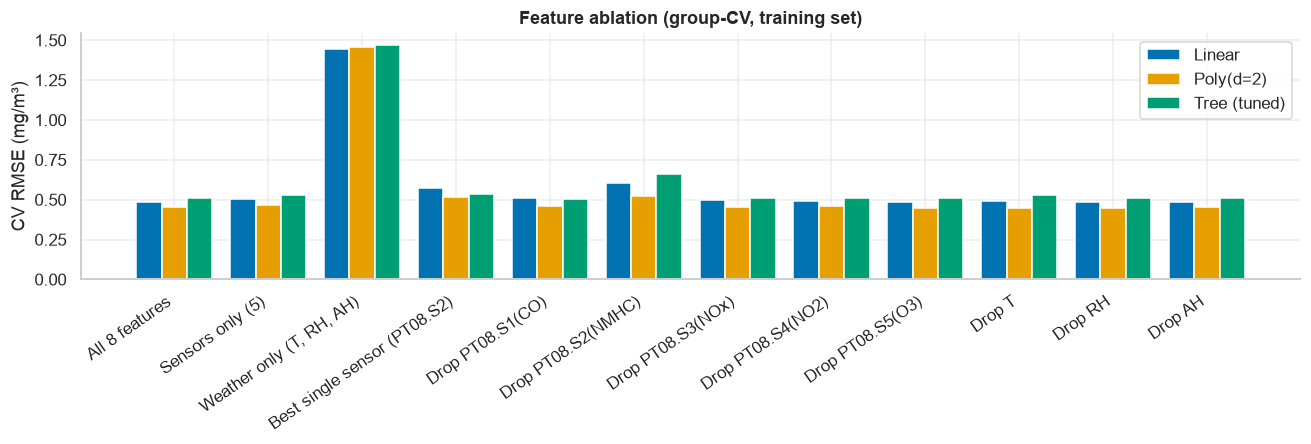

In [36]:
def make_linear(): return LinearRegressionScratch()
def make_poly():   return PolyRegressionScratch(DEG_STAR)
def make_tree():   return DecisionTreeRegressor(**TREE_BEST, random_state=SEED)
FACT = {"Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly, "Tree (tuned)": make_tree}

subsets = {"All 8 features": FEATURES, "Sensors only (5)": SENSOR_COLS, "Weather only (T, RH, AH)": WEATHER_COLS, "Best single sensor (PT08.S2)": ["PT08.S2(NMHC)"]}
subsets.update({f"Drop {f}": [c for c in FEATURES if c != f] for f in FEATURES})
rows = []
for sname, cols_ in subsets.items():
    for mname, mk in FACT.items():
        r = cv_eval(mk(), X=X_train_s[cols_]); rows.append({"feature set": sname, "model": mname, "n_features": len(cols_), "cv_rmse": r["cv_rmse"], "cv_rmse_sd": r["cv_rmse_sd"], "cv_r2": r["cv_r2"]})
ABL_FEAT = pd.DataFrame(rows)
tbl = ABL_FEAT.pivot(index="feature set", columns="model", values="cv_rmse").loc[list(subsets)]
base = tbl.loc["All 8 features"]; delta = (tbl - base)
display(pd.concat({"CV RMSE": tbl, "Δ vs all features": delta}, axis=1).style.format(precision=4).background_gradient(cmap="RdYlGn_r", subset=pd.IndexSlice[:, "Δ vs all features"]))

fig, ax = plt.subplots(figsize=(12, 4.2)); w = 0.27; xi = np.arange(len(tbl))
for i, (mname, c) in enumerate(zip(tbl.columns, [BLUE, ORANGE, GREEN])): ax.bar(xi + (i - 1) * w, tbl[mname], w, color=c, label=mname)
ax.set_xticks(xi); ax.set_xticklabels(tbl.index, rotation=35, ha="right"); ax.set_ylabel("CV RMSE (mg/m³)"); ax.set_title("Feature ablation (group-CV, training set)"); ax.legend()
plt.tight_layout(); plt.show()

**Observations — feature ablation (CV RMSE).**
- **Weather alone is useless** (≈ 1.44–1.47, i.e. the same as the mean predictor, 1.44): the weather variables carry almost no *direct* information about CO.
- **Sensors alone are almost as good as everything** (+0.014–0.016 RMSE): weather adds only a small correction (mostly via `T`, as the linear coefficient suggests).
- **`PT08.S2` is the one indispensable feature**: dropping it hurts every model (+0.12 linear, +0.07 polynomial, **+0.15 tree**), whereas dropping any other single feature changes CV RMSE by ≤ 0.02 (and sometimes improves it slightly): the sensors are mutually redundant.
- A **single feature (`PT08.S2`) already gets RMSE 0.52–0.58**, and the tree is least dependent on the other features (0.534 with S2 only).
- Dropping `T` hurts the tree (+0.017) but not the polynomial (−0.003): a possible reason (not tested) is that the polynomial can recover part of that information through sensor interaction terms.

**2.7.2 Preprocessing ablations** — (a) is standardisation really needed for gradient descent? (b) does a log-transformed target help (Stage 1 flagged the skew)? (c) does the tree split criterion matter?

,stable lr,train RMSE @ end,gap to OLS optimum
raw features,8.04578e-08,0.620901,0.141017
standardised,0.15,0.479884,6.93362e-12


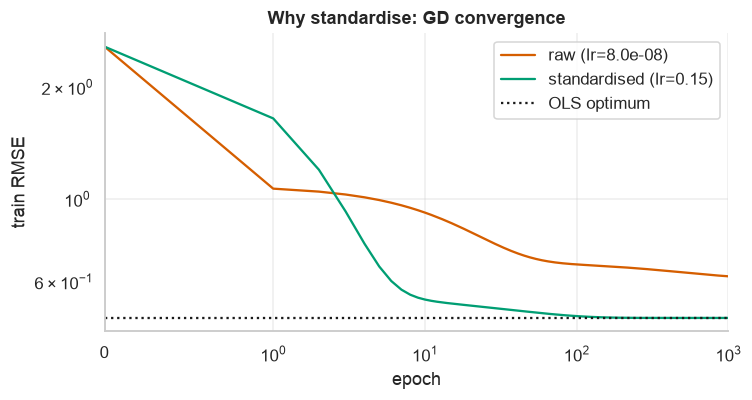

,CV RMSE (raw target),CV RMSE (log1p target),CV R² raw,CV R² log
model,,,,
Linear,0.4882,0.5237,0.8827,0.8623
Poly(d=2),0.4530,0.4488,0.8988,0.9002
Tree (tuned),0.5134,0.5121,0.8709,0.8707


,cv_rmse,cv_rmse_sd,cv_r2,cv_train_rmse
criterion,,,,
squared_error,0.5134,0.0478,0.8709,0.4687
friedman_mse,0.5134,0.0478,0.8709,0.4687
absolute_error,0.5019,0.0472,0.8762,0.4711
poisson,0.5060,0.0438,0.8744,0.4631


In [37]:
# (a) GD on RAW (unscaled) features vs standardised features, same epoch budget; lr = half the stability limit of each design matrix
Xr = LinearRegressionScratch._design(X_train.values); lam_r = np.linalg.eigvalsh(Xr.T @ Xr / len(Xr)).max(); lr_raw = 0.5 * 2 / (2 * lam_r)
raw = LinearRegressionScratch(solver="gd", lr=lr_raw, epochs=EPOCHS_LIN, track=True).fit(X_train, y_train)
sc = LinearRegressionScratch(solver="gd", lr=LR_LIN, epochs=EPOCHS_LIN, track=True).fit(X_train_s, y_train)
opt_rmse = RESULTS[N_LIN_NE]["train_rmse"]
ABL_SCALE = pd.DataFrame({"raw features": {"stable lr": lr_raw, "train RMSE @ end": raw.history_["train_rmse"].iloc[-1], "gap to OLS optimum": raw.history_["train_rmse"].iloc[-1] - opt_rmse},
                          "standardised": {"stable lr": LR_LIN, "train RMSE @ end": sc.history_["train_rmse"].iloc[-1], "gap to OLS optimum": sc.history_["train_rmse"].iloc[-1] - opt_rmse}}).T
display(ABL_SCALE.style.format("{:.6g}"))
fig, ax = plt.subplots(figsize=(7, 3.8)); ax.plot(raw.history_["epoch"], raw.history_["train_rmse"], color=RED, label=f"raw (lr={lr_raw:.1e})")
ax.plot(sc.history_["epoch"], sc.history_["train_rmse"], color=GREEN, label=f"standardised (lr={LR_LIN})"); ax.axhline(opt_rmse, color="k", ls=":", label="OLS optimum")
ax.set_yscale("log"); ax.set_xscale("symlog", linthresh=1); ax.set_xlim(0, EPOCHS_LIN); ax.set_xlabel("epoch"); ax.set_ylabel("train RMSE"); ax.set_title("Why standardise: GD convergence"); ax.legend(); plt.tight_layout(); plt.show()

# (b) log-target
log_models = {"Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly, "Tree (tuned)": make_tree}
rows = []
for mname, mk in log_models.items():
    base_ = cv_eval(mk()); logd = cv_eval(TransformedTargetRegressor(regressor=mk(), func=np.log1p, inverse_func=np.expm1))
    rows.append({"model": mname, "CV RMSE (raw target)": base_["cv_rmse"], "CV RMSE (log1p target)": logd["cv_rmse"], "CV R² raw": base_["cv_r2"], "CV R² log": logd["cv_r2"]})
ABL_LOG = pd.DataFrame(rows).set_index("model"); display(ABL_LOG.style.format(precision=4))

# (c) split criterion (tuned tree, CV)
rows = [{"criterion": c, **cv_eval(DecisionTreeRegressor(**TREE_BEST, criterion=c, random_state=SEED))} for c in ["squared_error", "friedman_mse", "absolute_error", "poisson"]]
ABL_CRIT = pd.DataFrame(rows).set_index("criterion")[["cv_rmse", "cv_rmse_sd", "cv_r2", "cv_train_rmse"]]; display(ABL_CRIT.style.format(precision=4))

**Observations — preprocessing ablations.**
- **Scaling is essential for gradient descent.** On raw features the largest stable learning rate is tiny, and after the same 1,000 epochs the training RMSE is 0.621 versus 0.480 for standardised inputs (the optimum): the badly scaled directions of the loss surface converge very slowly. This empirically supports the Stage 1 decision.
- **Log-target:** worse for the linear model (CV RMSE 0.488 → 0.524; a plausible cause is that the back-transform amplifies errors on the peaks, though this was not tested separately), neutral for the polynomial (0.453 → 0.449, within noise) and no effect for the tree. The raw target is retained.
- **Split criterion:** `absolute_error` (0.502) and `poisson` (0.506) are about 0.01 better than `squared_error`/`friedman_mse` (0.513, which are identical here), i.e. within one standard error (≈ 0.021) of each other. Since the assignment's metrics are MSE-based, `squared_error` is kept.

**2.7.3 Regularisation path for the linear model** — how do the coefficients (and the CV error) respond to L2 shrinkage under multicollinearity?

Best ridge alpha (linear) = 21.5; CV RMSE 0.4877 vs OLS 0.4882


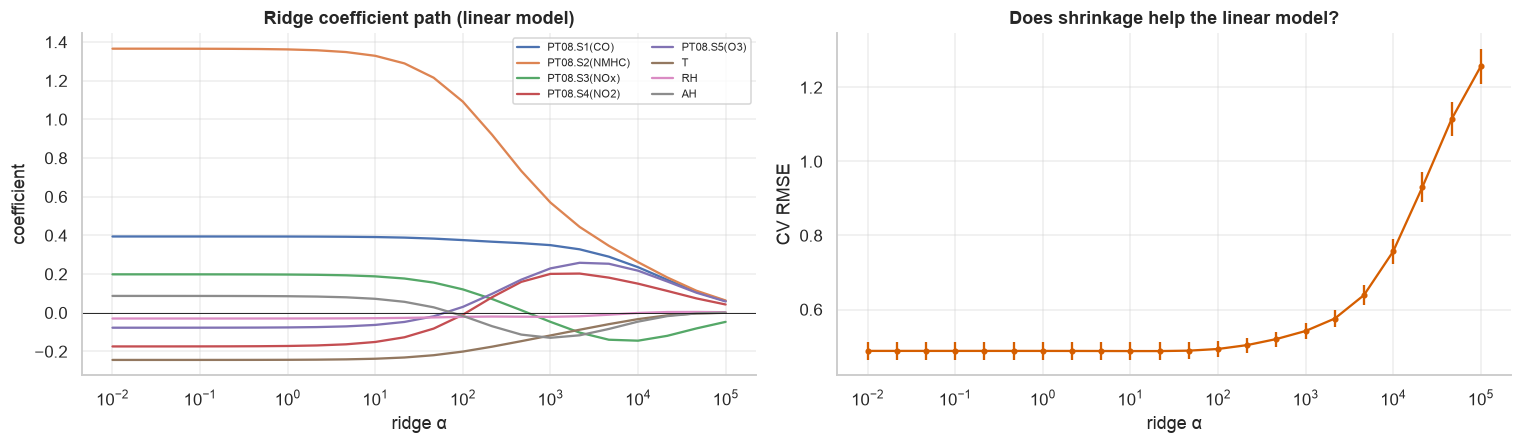

In [38]:
RIDGE_ALPHAS = np.logspace(-2, 5, 22)
path_rows, cv_rows = [], []
for a in RIDGE_ALPHAS:
    mdl = LinearRegressionScratch(alpha=a).fit(X_train_s, y_train); path_rows.append(pd.Series(mdl.coef_, index=FEATURES, name=a))
    cv_rows.append({"alpha": a, **cv_eval(LinearRegressionScratch(alpha=a))})
RIDGE_PATH, RIDGE_CV = pd.DataFrame(path_rows), pd.DataFrame(cv_rows).set_index("alpha")
a_best = RIDGE_CV["cv_rmse"].idxmin(); print(f"Best ridge alpha (linear) = {a_best:.3g}; CV RMSE {RIDGE_CV.loc[a_best, 'cv_rmse']:.4f} vs OLS {RIDGE_CV.iloc[0]['cv_rmse']:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for f in FEATURES: ax[0].plot(RIDGE_PATH.index, RIDGE_PATH[f], label=f)
ax[0].set_xscale("log"); ax[0].axhline(0, color="k", lw=.6); ax[0].set_xlabel("ridge α"); ax[0].set_ylabel("coefficient"); ax[0].set_title("Ridge coefficient path (linear model)"); ax[0].legend(fontsize=7, ncol=2)
ax[1].errorbar(RIDGE_CV.index, RIDGE_CV["cv_rmse"], yerr=RIDGE_CV["cv_rmse_sd"] / np.sqrt(len(folds)), color=RED, marker="o", ms=3); ax[1].set_xscale("log")
ax[1].set_xlabel("ridge α"); ax[1].set_ylabel("CV RMSE"); ax[1].set_title("Does shrinkage help the linear model?"); plt.tight_layout(); plt.show()

**Observation.** Ridge shrinkage does **not** improve the linear model (best α ≈ 21: CV RMSE 0.4877 vs. 0.4882 for OLS) and large α quickly hurts. The multicollinearity found in Stage 1 therefore affects the *interpretation* of individual coefficients (the coefficient paths of the correlated sensors cross and change sign as α grows), but **not the predictive accuracy**.

### 2.8 Learning curves, per-regime errors and out-of-time robustness
* **Learning curves** (group-CV): is more data likely to help each model, or is it bias-limited?
* **Per-regime errors** on the test set: where (Low … Very-high CO) does each model fail? (Stage 1 flagged the 8:1 imbalance.)
* **Out-of-time check**: refit with *fixed* hyper-parameters on the first 80 % of the timeline and test on the last 20 % — the chronological protocol rejected as the default in Stage 1.

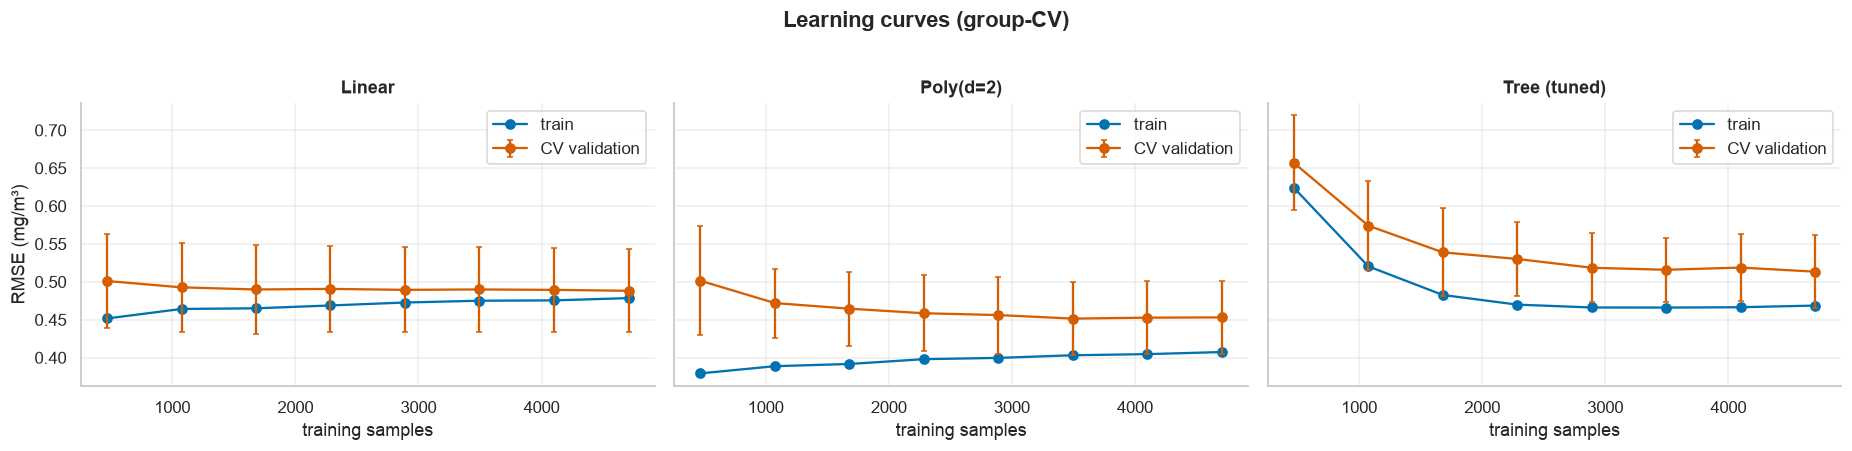

In [39]:
LC = {}
sizes = np.linspace(0.1, 1.0, 8)
for mname, mk in FACT.items():
    ts, trs, vas = learning_curve(mk(), X_train_s, y_train, groups=groups, cv=cv, train_sizes=sizes, scoring="neg_root_mean_squared_error", shuffle=True, random_state=SEED)[0:3]
    LC[mname] = pd.DataFrame({"n_train": ts, "train_rmse": -trs.mean(1), "val_rmse": -vas.mean(1), "val_rmse_sd": vas.std(1)}).set_index("n_train")
fig, ax = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for a, (mname, df_) in zip(ax, LC.items()):
    a.plot(df_.index, df_["train_rmse"], color=BLUE, marker="o", label="train"); a.errorbar(df_.index, df_["val_rmse"], yerr=df_["val_rmse_sd"], color=RED, marker="o", capsize=2, label="CV validation")
    a.set_title(mname); a.set_xlabel("training samples"); a.legend()
ax[0].set_ylabel("RMSE (mg/m³)"); plt.suptitle("Learning curves (group-CV)", y=1.02, fontweight="bold"); plt.tight_layout(); plt.show()
display(pd.concat({k: v.iloc[[0, 3, -1]] for k, v in LC.items()}).style.format(precision=4))

**Observations.**
- **Linear:** training and validation RMSE are flat and almost equal (0.478 vs. 0.488) already from ~500 samples → high bias; **more data will not help**, a more flexible model might.
- **Poly d=2:** a small, shrinking gap (0.407 vs. 0.453) and a validation curve that is nearly flat from ~3,000 samples: close to its capacity.
- **Tuned tree:** the largest data hunger — validation error falls from 0.657 (n=470) to ≈ 0.52 at n ≈ 2,900 and then plateaus.
- Fold-to-fold spread (error bars, ≈ ±0.05) is of the same order as the differences between the models, so differences below ~0.03 RMSE should not be over-interpreted.

In [40]:
FINAL = [N_MEAN, N_LIN_NE, N_POLY_NE, N_PR_SC, tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T]
bt_test = pd.cut(y_test, bands_edges, labels=bands_labels, right=False)
rows = []
for nm in FINAL:
    err = PRED[nm]["test"] - y_test.values
    for b in bands_labels:
        mk_ = (bt_test == b).values; rows.append({"model": nm, "regime": b, "n": int(mk_.sum()), "rmse": np.sqrt(np.mean(err[mk_] ** 2)), "mae": np.mean(np.abs(err[mk_])), "bias (pred-true)": err[mk_].mean()})
REGIME = pd.DataFrame(rows)
display(REGIME.pivot(index="model", columns="regime", values="rmse")[bands_labels].loc[FINAL].style.format(precision=3).background_gradient(cmap="RdYlGn_r", axis=None).set_caption("Test RMSE by CO regime"))
display(REGIME.pivot(index="model", columns="regime", values="bias (pred-true)")[bands_labels].loc[FINAL].style.format(precision=3).background_gradient(cmap="coolwarm", axis=None, vmin=-3, vmax=3).set_caption("Mean error (pred − true) by CO regime: negative = under-prediction"))

# residual artefacts for Stage 3
RESID = {nm: {"train": y_train.values - PRED[nm]["train"], "test": y_test.values - PRED[nm]["test"]} for nm in PRED}

regime,Low (<1.5),Moderate (1.5-3),High (3-5),Very high (>=5)
model,,,,
Baseline | mean predictor,1.302,0.427,1.731,3.984
Linear | scratch (normal eq.),0.384,0.433,0.519,1.173
Poly(d=2) | scratch (normal eq.),0.326,0.391,0.559,0.946
Poly(d=2)+Ridge(α=1) | scratch,0.326,0.391,0.561,0.949
Tree | max_depth=3,0.405,0.508,0.725,1.327
Tree | max_depth=5,0.361,0.437,0.646,1.152
Tree | max_depth=10,0.356,0.441,0.771,1.149
Tree | max_depth=None,0.386,0.515,0.886,1.190
"Tree | tuned (CV, 1-SE)",0.361,0.437,0.653,1.161


regime,Low (<1.5),Moderate (1.5-3),High (3-5),Very high (>=5)
model,,,,
Baseline | mean predictor,1.256,0.047,-1.637,-3.878
Linear | scratch (normal eq.),0.012,0.101,-0.085,-0.927
Poly(d=2) | scratch (normal eq.),0.089,-0.007,-0.114,-0.555
Poly(d=2)+Ridge(α=1) | scratch,0.090,-0.007,-0.114,-0.557
Tree | max_depth=3,0.166,-0.008,-0.220,-0.710
Tree | max_depth=5,0.119,-0.016,-0.133,-0.660
Tree | max_depth=10,0.089,-0.011,-0.190,-0.503
Tree | max_depth=None,0.076,-0.009,-0.197,-0.414
"Tree | tuned (CV, 1-SE)",0.119,-0.016,-0.126,-0.556


**Observations — where do the models fail?**
- **All models under-predict the rare *Very high* hours** (mean error −0.93 linear, −0.56 polynomial, −0.56 tuned tree, −0.41 unrestricted tree) and their RMSE is 2–3× larger there than in the other regimes (0.95–1.19 vs. 0.33–0.65). This is the consequence of the 8:1 imbalance flagged in Stage 1: the squared-error objective is dominated by the bulk of the data.
- The polynomial model is best in the Low (0.326), Moderate (0.391) and Very-high (0.946) regimes; the **linear model is best in the High regime** (0.519 vs. 0.559 polynomial, 0.653 tuned tree).
- Overall RMSE therefore hides substantial regime-dependent differences; Stage 3 will use these tables.

In [41]:
cut = int(len(data) * 0.8); Xo_tr, Xo_te, yo_tr, yo_te = data[FEATURES].iloc[:cut], data[FEATURES].iloc[cut:], data[TARGET].iloc[:cut], data[TARGET].iloc[cut:]
OOT_MODELS = {"Mean baseline": lambda: DummyRegressor(), "Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly,
              f"Poly(d={DEG_R})+Ridge": lambda: PolyRegressionScratch(DEG_R, alpha=ALPHA_R), "Tree max_depth=5": lambda: DecisionTreeRegressor(max_depth=5, random_state=SEED),
              "Tree (tuned)": make_tree}
rows = []
for mname, mk in OOT_MODELS.items():
    pipe = Pipeline([("scale", StandardScaler()), ("m", mk())]).fit(Xo_tr, yo_tr)
    rows.append({"model": mname, "oot_train_rmse": rmse(yo_tr, pipe.predict(Xo_tr)), "oot_test_rmse": rmse(yo_te, pipe.predict(Xo_te)), "oot_test_r2": r2(yo_te, pipe.predict(Xo_te)), "oot_test_mae": mae(yo_te, pipe.predict(Xo_te))})
OOT = pd.DataFrame(rows).set_index("model")
OOT["random-split test RMSE"] = [RESULTS[n]["test_rmse"] for n in [N_MEAN, N_LIN_NE, N_POLY_NE, N_PR_SC, tree_names[5], N_TREE_T]]
OOT["degradation (oot - random)"] = OOT["oot_test_rmse"] - OOT["random-split test RMSE"]
print(f"Out-of-time split: train {Xo_tr.index.min():%d %b %Y} – {Xo_tr.index.max():%d %b %Y}, test {Xo_te.index.min():%d %b %Y} – {Xo_te.index.max():%d %b %Y}")
display(OOT.style.format(precision=4))

Out-of-time split: train 10 Mar 2004 – 28 Jan 2005, test 28 Jan 2005 – 04 Apr 2005


,oot_train_rmse,oot_test_rmse,oot_test_r2,oot_test_mae,random-split test RMSE,degradation (oot - random)
model,,,,,,
Mean baseline,1.4650,1.3197,-0.0299,1.0677,1.4232,-0.1035
Linear,0.4845,0.4836,0.8617,0.3437,0.4933,-0.0097
Poly(d=2),0.4140,0.4460,0.8824,0.3020,0.4470,-0.0011
Poly(d=2)+Ridge,0.4144,0.4427,0.8841,0.2980,0.4474,-0.0047
Tree max_depth=5,0.4493,0.5276,0.8354,0.3600,0.5131,0.0145
Tree (tuned),0.4651,0.5126,0.8446,0.3544,0.5157,-0.0031


**Observations — out-of-time robustness (hyper-parameters fixed, *not* re-tuned).**
- Contrary to the concern raised in Stage 1, the chronological split is **not materially harder** in RMSE: linear 0.484 (vs. 0.493 random), polynomial 0.446 (0.447), tuned tree 0.513 (0.516). Despite the clear covariate shift in `T`, `AH` and `PT08.S4`, the CO ↔ sensor relationship (dominated by `PT08.S2`) is stable across seasons.
- The ranking is unchanged: **polynomial < linear < trees**; the plain depth-5 tree degrades slightly (0.513 → 0.528) while the tuned tree does not.
- R² is lower out-of-time for the linear model (0.862 vs. 0.880) because the later test period has lower CO variance (the mean predictor scores RMSE 1.32 there).
- This is one split, so it supports the conclusion but is not a precise estimate of forecasting error.

### 2.9 Hand-off to Stages 3–6 and sanity checks

In [42]:
art = pd.DataFrame({"artifact": ["RESULTS / MASTER", "FITTED", "PRED", "RESID", "HISTORY", "TREE_SWEEP", "POLY_CV (agg)", "IMP_TREE", "PERM", "COEF_BOOT",
                                 "ABL_FEAT", "ABL_SCALE / ABL_LOG / ABL_CRIT", "RIDGE_PATH / RIDGE_CV", "LC", "REGIME", "OOT"],
                    "content": ["train/test MSE, RMSE, R², MAE (+CV) for 15 models", "fitted estimators (trees can be plotted)", "train/test predictions per model",
                                "train/test residuals per model", "per-epoch train/test metrics for the 2 gradient-based models",
                                "train/CV/test metrics for depth 1-20 and None", "degree × α CV grid", "impurity importances per tree",
                                "permutation importances on test", "linear coefficients with bootstrap CIs", "feature-group and drop-one ablation",
                                "scaling, log-target and criterion ablations", "ridge coefficient path and CV", "learning curves", "per-regime RMSE/MAE/bias", "out-of-time results"]}).set_index("artifact")
display(art)
assert set(HISTORY) == {N_LIN_GD, N_POLY_GD} and all(np.isfinite(HISTORY[k].values).all() for k in HISTORY)
assert all(np.isfinite(MASTER[["train_rmse", "test_rmse"]].values).ravel())
print("Registry holds", len(RESULTS), "models; histories:", {k: len(v) for k, v in HISTORY.items()}, "epochs")

,content
artifact,
RESULTS / MASTER,"train/test MSE, RMSE, R², MAE (+CV) for 15 models"
FITTED,fitted estimators (trees can be plotted)
PRED,train/test predictions per model
RESID,train/test residuals per model
HISTORY,per-epoch train/test metrics for the 2 gradien...
TREE_SWEEP,train/CV/test metrics for depth 1-20 and None
POLY_CV (agg),degree × α CV grid
IMP_TREE,impurity importances per tree
PERM,permutation importances on test


Registry holds 15 models; histories: {'Linear | scratch (GD)': 1001, 'Poly(d=2) | scratch (Adam GD)': 3001} epochs


**Stage 2 take-aways (feeding the later stages)**
1. All from-scratch models match scikit-learn; selection used leakage-safe group-CV only.
2. Polynomial degree 2 is the CV-optimal and 1-SE degree; linear is bias-limited; trees are best at depth ≈ 5–6 with ≈ 20–30 leaves.
3. `PT08.S2(NMHC)` is the dominant feature in every model and ablation; weather alone is uninformative but adds a small correction.
4. All models under-predict the rare high-CO episodes.
5. Results are stable under an out-of-time split.

✅ **Stage 2 complete** — models trained, verified against scikit-learn, tuned with leakage-safe CV, and every artifact needed for the evaluation, visualisation, comparison and discussion stages is stored.

---
## Stage 3 — Model Evaluation *(next)*